### Accessing the Data

In [ ]:
icu_patients_df0 <- readRDS("icu_patients_df0.rds")
icu_patients_df1 <- readRDS("icu_patients_df1.rds")

### **Overview**
This analysis uses ICU patient data to investigate in-hospital mortality and subsequent survival time. In the explanatory analysis, we wanted to identify and quantify the association between clinically meaningful patient characteristics and the risk of in-hospital death. An explanatory focus prioritises interpretable coefficients and clinical reasoning over predictive accuracy metrics. In a clinical setting, understanding which factors drive mortality risk — and by how much — is directly actionable for patient care and resource allocation. For the survival analysis, Cox PH models are predominantly used for prognosis, and therefore we thought it would be more useful to predict survival probability over time for individual patients. Moreover, the outcome (Days + Status) captures whether and when death occurs and is an appropriate outcome for a prediction task, thereby helping clinicians estimate individual patient trajectories.

The initial set of candidate clinical measures were selected based on established clinical relevance to ICU mortality, organised by discrete physiological (organ system) domains. The following clinical variables were included in the initial feature set:

| Clinical Domain | Variables | Sources|
|---|---|---|
|Patient characteristics| Age, ICUType, Gender| Ros et al., 2021; Sun et al., 2025|
|Renal| BUN, Creatinine, Urine| Nielsen et al., 2019; Sun et al., 2025; Tu et al., 2025 |
|Hepatic/Metabolic| Bilirubin, Albumin, Lactate|Iwase et al., 2022; Nielsen et al., 2019; Vincent et al., 2003|
|Acid-base| HCO3, pH |Tu et al., 2025; Chiu et al., 2022|
|Haematological| HCT, Platelets|Iwase et al., 2022; Gharibeh et al., 2025|
|Cardiovascular| HR, MAP|Hang et al., 2025; Sun et al., 2025|
|Respiratory| RespRate| Sun et al., 2025|
|Neurological| GCS| Sun et al., 2025; Hang et al., 2025|
|Electrolytes| K|Sun et al., 2025|

As both outcomes reflect critical illness severity, the same physiological systems that explain whether someone dies in hospital are largely the same ones that predict when and whether they die over follow-up (Knaus et al., 1985; Vincent et al., 1996). Thus, the initial list of features for univariate testing remain the same for both tasks. Nevertheless, subsequent feature retention is determined by the model's objective and variables are selected if they could help explain ICU mortality (the explanatory analysis) or if they demonstrate evidence of being strong predictors of survival time following an ICU visit.

The most extreme physiological state recorded (_max or _min variables) are more directly interpretable for both tasks than their overall fluctuation (_diff).  Variables with _diff were thus excluded as they could conflate directional changes. For example, the same value in *temp_diff* can represent fever or hypothermia. We were reluctant to include measures which could carry variable meaning and thus compromise coefficient interpretability or prediction. Thus, for each continuous clinical measure, the covariate direction most directly reflecting physiological severity was selected when used in either tasks (e.g., BUN_max and RespRate_max reflect worsening renal and respiratory function, while HCT_min and pH_min reflect anemia and acidosis respectively).

The following variables were excluded as features from both tasks:
- *Excessive missingnes*:  NIDiasABP/NIMAP/NISysABP, DiasABP/SysABP, Height, Weight
- *Absent from dataset*: MechVent
- *Identifier or outcome variables*: RecordID, in_hospital_death, Length_of_stay, Survival, Days, Status
- *Limited clinical effect for ICU mortality in literature*: ALP, ALT, AST, Cholesterol, Mg, PaCO2, TropT, TropI, SaO2
- *Captured in composite scores; limited independent evidence*| Glucose, Na, Temp, WBC (SAPS1);  PaO2, FiO2 (SOFA)

In [ ]:
untar("/content/hdat9600_libs.tar.gz", exdir="/usr/local/lib/R/site-library")
.libPaths("/usr/local/lib/R/site-library/my_libs")
install.packages("ROCR"); install.packages("survminer")

Installing package into ‘/usr/local/lib/R/site-library/my_libs’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bitops’, ‘gtools’, ‘caTools’, ‘gplots’


Installing package into ‘/usr/local/lib/R/site-library/my_libs’
(as ‘lib’ is unspecified)

also installing the dependencies ‘litedown’, ‘corrplot’, ‘markdown’, ‘png’, ‘jpeg’, ‘ggrepel’, ‘ggsci’, ‘ggsignif’, ‘polynom’, ‘rstatix’, ‘exactRankTests’, ‘gridtext’, ‘ggpubr’, ‘maxstat’, ‘ggtext’




In [208]:
options(repr.plot.width = 10, repr.plot.height = 5); options(warn = -1)

In [211]:
library(dplyr); library(faraway); library(tidyr); library(ggplot2); library(DescTools);
library(arm); library(survival); library(bshazard); library(eha); library(ROCR);
library(survminer); library(car)

In [212]:
# Check data structure
str(icu_patients_df1); glimpse(icu_patients_df1)

'data.frame':	2061 obs. of  123 variables:
 $ RecordID         : num  132539 132540 132541 132543 132545 ...
 $ Length_of_stay   : num  5 8 19 9 4 6 9 6 17 8 ...
 $ SAPS1            : num  6 16 21 7 17 14 14 19 11 14 ...
 $ SOFA             : num  1 8 11 1 2 11 4 8 0 6 ...
 $ Survival         : num  NA NA NA 575 918 ...
 $ in_hospital_death: Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 2 1 1 ...
 $ Days             : num  2408 2408 2408 575 918 ...
 $ Status           : logi  FALSE FALSE FALSE TRUE TRUE TRUE ...
 $ Age              : num  54 76 44 68 88 64 68 78 64 74 ...
 $ Albumin_diff     : num  0.219 0.881 0.681 1.419 0.381 ...
 $ Albumin_max      : num  3.2 2.1 2.7 4.4 2.7 3.4 3.9 1.9 2.8 3.4 ...
 $ Albumin_min      : num  3.1 2.2 2.3 4.4 2.6 3.3 3.9 1.9 2.7 3.4 ...
 $ ALP_diff         : num  118.15 252.15 31.15 9.15 56.85 ...
 $ ALP_max          : num  214 338 127 105 39 101 362 47 338 59 ...
 $ ALP_min          : num  202 348 105 105 78 101 341 47 405 67 ...
 $ ALT_diff         : n

In [213]:
# Data summary
summary(icu_patients_df1); summary(icu_patients_df0)

    RecordID      Length_of_stay       SAPS1            SOFA       
 Min.   :132539   Min.   :  2.00   Min.   : 1.00   Min.   : 0.000  
 1st Qu.:133875   1st Qu.:  6.00   1st Qu.:11.00   1st Qu.: 3.000  
 Median :135146   Median : 10.00   Median :15.00   Median : 7.000  
 Mean   :135156   Mean   : 13.92   Mean   :14.96   Mean   : 6.683  
 3rd Qu.:136477   3rd Qu.: 17.00   3rd Qu.:19.00   3rd Qu.: 9.000  
 Max.   :137740   Max.   :154.00   Max.   :34.00   Max.   :22.000  
                  NA's   :25       NA's   :96      NA's   :65      
    Survival      in_hospital_death      Days        Status       
 Min.   :   0.0   0:1764            Min.   :   0   Mode :logical  
 1st Qu.:  10.0   1: 297            1st Qu.: 265   FALSE:1288     
 Median :  68.0                     Median :2408   TRUE :773      
 Mean   : 343.1                     Mean   :1634                  
 3rd Qu.: 420.0                     3rd Qu.:2408                  
 Max.   :2408.0                     Max.   :2408      

    RecordID      Length_of_stay       SAPS1            SOFA       
 Min.   :132539   Min.   :  2.00   Min.   : 1.00   Min.   : 0.000  
 1st Qu.:133875   1st Qu.:  6.00   1st Qu.:11.00   1st Qu.: 3.000  
 Median :135146   Median : 10.00   Median :15.00   Median : 7.000  
 Mean   :135156   Mean   : 13.92   Mean   :14.96   Mean   : 6.683  
 3rd Qu.:136477   3rd Qu.: 17.00   3rd Qu.:19.00   3rd Qu.: 9.000  
 Max.   :137740   Max.   :154.00   Max.   :34.00   Max.   :22.000  
                  NA's   :25       NA's   :96      NA's   :65      
    Survival      in_hospital_death      Days        Status       
 Min.   :   0.0   0:1764            Min.   :   0   Mode :logical  
 1st Qu.:  10.0   1: 297            1st Qu.: 265   FALSE:1288     
 Median :  68.0                     Median :2408   TRUE :773      
 Mean   : 343.1                     Mean   :1634                  
 3rd Qu.: 420.0                     3rd Qu.:2408                  
 Max.   :2408.0                     Max.   :2408      

In [214]:
# Factoring and releveling
icu_patients_df1$in_hospital_death <- as.factor(icu_patients_df1$in_hospital_death)
icu_patients_df0$in_hospital_death <- as.factor(icu_patients_df0$in_hospital_death)
icu_patients_df1$ICUType <- relevel(icu_patients_df1$ICUType, ref = "Medical ICU")
icu_patients_df0$ICUType <- relevel(icu_patients_df0$ICUType, ref = "Medical ICU")

In [215]:
# Filtering out physiologically impossible values
icu_patients_df1$MAP_min[icu_patients_df1$MAP_min < 10] <- NA
icu_patients_df0$MAP_min[icu_patients_df0$MAP_min < 10] <- NA
icu_patients_df1$HR_max[icu_patients_df1$HR_max > 280] <- NA
icu_patients_df0$HR_max[icu_patients_df0$HR_max > 280] <- NA
icu_patients_df1$RespRate_max[icu_patients_df1$RespRate_max > 80] <- NA
icu_patients_df0$RespRate_max[icu_patients_df0$RespRate_max > 80] <- NA
icu_patients_df1$K_max[icu_patients_df1$K_max > 12] <- NA
icu_patients_df0$K_max[icu_patients_df0$K_max > 12] <- NA
icu_patients_df1$pH_min[icu_patients_df1$pH_min < 6.5] <- NA
icu_patients_df0$pH_min[icu_patients_df0$pH_min < 6.5] <- NA
icu_patients_df1$SOFA[icu_patients_df1$SOFA == -1] <- NA
icu_patients_df0$SOFA[icu_patients_df0$SOFA == -1] <- NA
icu_patients_df1$Length_of_stay[icu_patients_df1$Length_of_stay == -1] <- NA
icu_patients_df0$Length_of_stay[icu_patients_df0$Length_of_stay == -1] <- NA

In [216]:
# Identify missing patients for SAPS1 SOFA, Length of stay
icu_patients_df1$saps_missing <- is.na(icu_patients_df1$SAPS1)
icu_patients_df1$sofa_missing <- is.na(icu_patients_df1$SOFA)
icu_patients_df1$length_missing <- is.na(icu_patients_df1$Length_of_stay)
table(icu_patients_df1$saps_missing, icu_patients_df1$in_hospital_death)
table(icu_patients_df1$sofa_missing, icu_patients_df1$in_hospital_death)
table(icu_patients_df1$length_missing, icu_patients_df1$in_hospital_death)

       
           0    1
  FALSE 1680  285
  TRUE    84   12

       
           0    1
  FALSE 1703  293
  TRUE    61    4

       
           0    1
  FALSE 1739  297
  TRUE    25    0

In [217]:
# Outcome distribution
cat("Mortality in dataset:\n"); table(icu_patients_df1$in_hospital_death)
cat("Total patients:", nrow(icu_patients_df1), "\n")
cat("Events (deaths):", sum(icu_patients_df1$Status), "\n")
cat("Censored:", sum(!icu_patients_df1$Status), "\n")
cat("Event rate:", round(mean(icu_patients_df1$Status)*100, 1), "%\n")
cat("Follow-up range:", min(icu_patients_df1$Days), "to", max(icu_patients_df1$Days))

Mortality in dataset:



   0    1 
1764  297 

Total patients: 2061 
Events (deaths): 773 
Censored: 1288 
Event rate: 37.5 %
Follow-up range: 0 to 2408

**Dataset Review**

The dataset contains 2,061 patients with 14.4% in-hospital mortality. There are 773 deaths and 1,288 censored observations (event rate 37.5%, 62.5% censored), with follow-up ranging from 0 to 2,408 days. Several variables have substantial missingness in df1: DiasABP/SysABP (715 NAs), NIDiasABP/NIMAP/NISysABP (~455 NAs), Height (992 NAs), Weight (146 NAs). MechVent variables do not appear in this dataset and were excluded. Missingness in SOFA and SAPS1 appears non-random but not severe. Patients with missing SOFA have lower mortality (6.2%) compared to those with missing SAPS1 (12.5%), while patients with observed values for both scores have comparable mortality rates (SOFA: 14.7%, SAPS1: 14.5%). This suggests missingness is related to patient acuity rather than data quality issues, but neither score's missingness was severe enough to disqualify it from consideration. Records missing Length_of_stay have zero deaths, suggesting these possibly represent administrative records or very short stays.

# **Explanatory model: predictors of in-hospital mortality**
SAPS1 is a composite admission-based mortality prediction score that incorporates Age and 13 other physiological variables related to mortality (Afessa et al., 2007). Including it in an explanatory model would affect how these variables are modelled individually and masks the effects we are trying to explain. In contrast, SOFA captures organ failure severity across six systems (respiratory, coagulation, hepatic, cardiovascular, neurological, renal) and leaves room to include individual physiologic variables alongside it, enabling a richer and more interpretable explanatory model (Afessa et al., 20071). As both scores are highly correlated, using only SOFA in the model as the clinical score limits multicollinearity and is better suited to explain the organ-systems effecs related to mortality.

*Note: Urine, Platelets, MAP, Creatinine, and Bilirubin overlap with SOFA component variables, however, as they are individually prominent in the ICU mortality literature and not highly correlated with SOFA, they are tested univariately. GCS was included despite high correlation with SOFA given its prominence in both SOFA and SAPS1.*

In [218]:
# Categorical variables by target
print(table(icu_patients_df1$ICUType, icu_patients_df1$in_hospital_death))
print(table(icu_patients_df1$Gender, icu_patients_df1$in_hospital_death))

                               
                                  0   1
  Medical ICU                   642 146
  Coronary Care Unit            249  48
  Cardiac Surgery Recovery Unit 422  26
  Surgical ICU                  451  77
        
           0   1
  Female 780 133
  Male   984 164


,Age,GCS_min,MAP_min,Lactate_max,Creatinine_max,Urine_min,PaO2_min,Platelets_min,Bilirubin_max,Albumin_min,BUN_max,HCO3_min,HR_max,SOFA,SAPS1,RespRate_max,K_max,pH_min,HCT_min
Age,1.00000000,0.03761234,-0.16522645,-0.03332089,0.020588541,-0.16954325,-0.06760630,-0.035598888,-0.05908715,-0.01570631,0.20585410,0.03946346,-0.14537136,0.07057917,0.28311567,-0.077245306,0.01235607,0.04922658,-0.05785592
GCS_min,0.03761234,1.00000000,0.17359855,-0.18676490,0.011432624,0.30649759,-0.02111652,0.217242874,-0.05451439,0.13205689,0.07112748,0.13127522,-0.08648735,-0.71325388,-0.64292574,-0.146535271,-0.12260046,0.23159030,0.20457911
MAP_min,-0.16522645,0.17359855,1.00000000,-0.06846403,-0.048801986,0.17148583,0.11661767,0.088735047,0.08066614,0.08218695,-0.03499008,0.10796739,-0.05056400,-0.25806379,-0.26462577,0.052389953,-0.09927605,0.18049746,0.21454223
Lactate_max,-0.03332089,-0.18676490,-0.06846403,1.00000000,0.078556018,-0.01806831,-0.10385029,-0.164564188,0.18759772,-0.11794389,0.04745238,-0.32233549,0.21947366,0.33124414,0.28565226,0.140320988,0.11518287,-0.33786287,-0.16867703
Creatinine_max,0.02058854,0.01143262,-0.04880199,0.07855602,1.000000000,-0.06904766,0.01973779,-0.005837291,0.12031225,-0.01952655,0.66668809,-0.24858347,-0.02479898,0.27042212,0.17623505,0.102205188,0.24489508,-0.14902138,-0.03848080
Urine_min,-0.16954325,0.30649759,0.17148583,-0.01806831,-0.069047662,1.00000000,0.01135870,0.089328761,-0.02136362,0.11265537,-0.07862810,0.10961468,-0.04641962,-0.31131559,-0.32026647,-0.071703137,-0.11180902,0.09068659,0.19998887
PaO2_min,-0.06760630,-0.02111652,0.11661767,-0.10385029,0.019737794,0.01135870,1.00000000,0.025499477,-0.02246718,0.11099446,-0.07488044,0.03848020,-0.09033273,-0.17274048,-0.05306778,-0.014861568,-0.11947371,0.20608394,0.01490704
Platelets_min,-0.03559889,0.21724287,0.08873505,-0.16456419,-0.005837291,0.08932876,0.02549948,1.000000000,-0.13037572,0.10804895,-0.01236030,0.09053184,0.03910528,-0.33982050,-0.19434131,0.009050942,-0.01666402,0.06409926,0.22523000
Bilirubin_max,-0.05908715,-0.05451439,0.08066614,0.18759772,0.120312254,-0.02136362,-0.02246718,-0.130375716,1.00000000,-0.07853191,0.12122977,-0.08046655,0.02169636,0.18983254,0.08579276,0.185800898,0.07240400,-0.02957134,-0.08684782
Albumin_min,-0.01570631,0.13205689,0.08218695,-0.11794389,-0.019526546,0.11265537,0.11099446,0.108048950,-0.07853191,1.00000000,-0.07124517,0.17845938,-0.13915749,-0.25856341,-0.18501229,-0.032749195,-0.06646985,0.11707968,0.22319998


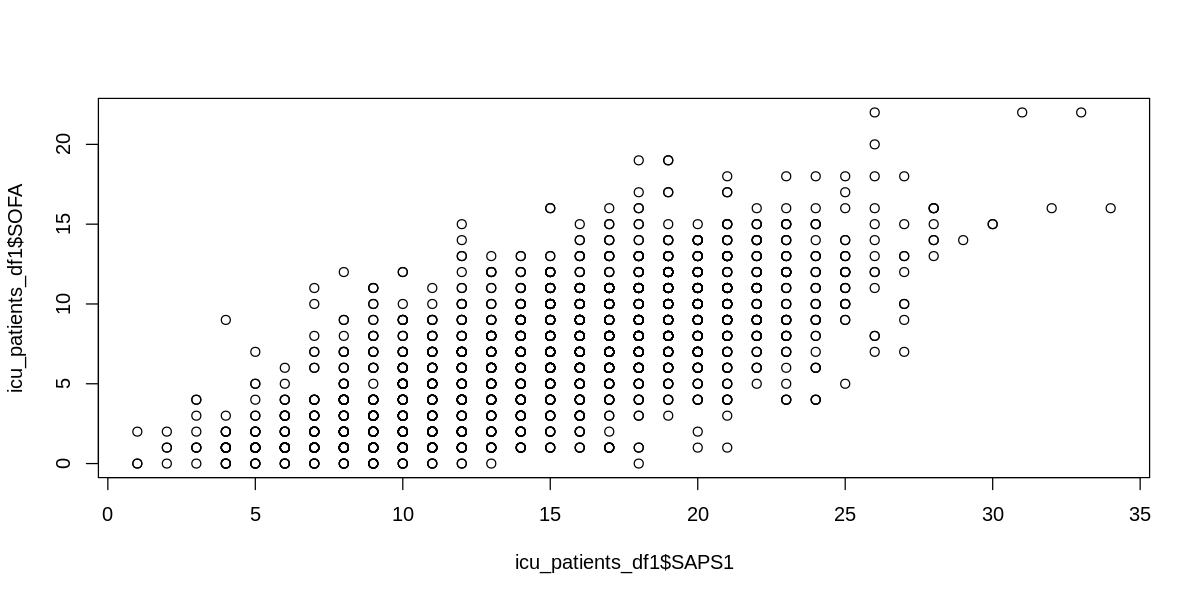

In [219]:
# Correlations
cont_vars <- c("Age", "GCS_min", "MAP_min", "Lactate_max", "Creatinine_max", "Urine_min",
               "PaO2_min", "Platelets_min", "Bilirubin_max", "Albumin_min", "BUN_max",
               "HCO3_min", "HR_max","SOFA", "SAPS1", "RespRate_max", "K_max", "pH_min",
               "HCT_min")
cor(icu_patients_df1[, cont_vars], use = "complete.obs")
plot(icu_patients_df1$SAPS1, icu_patients_df1$SOFA)

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


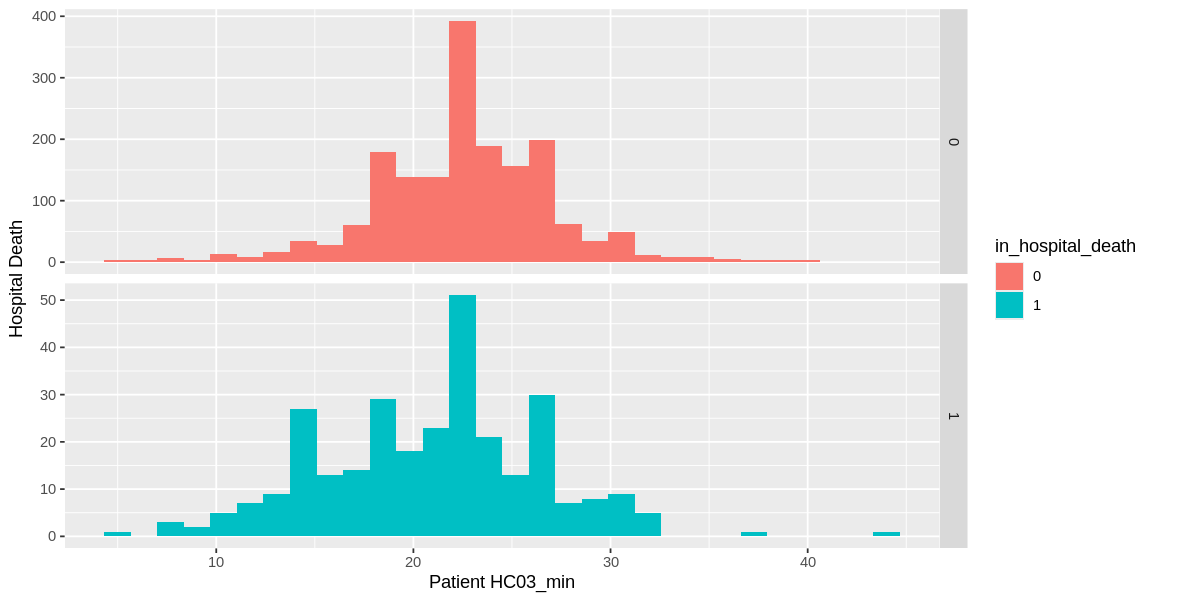

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


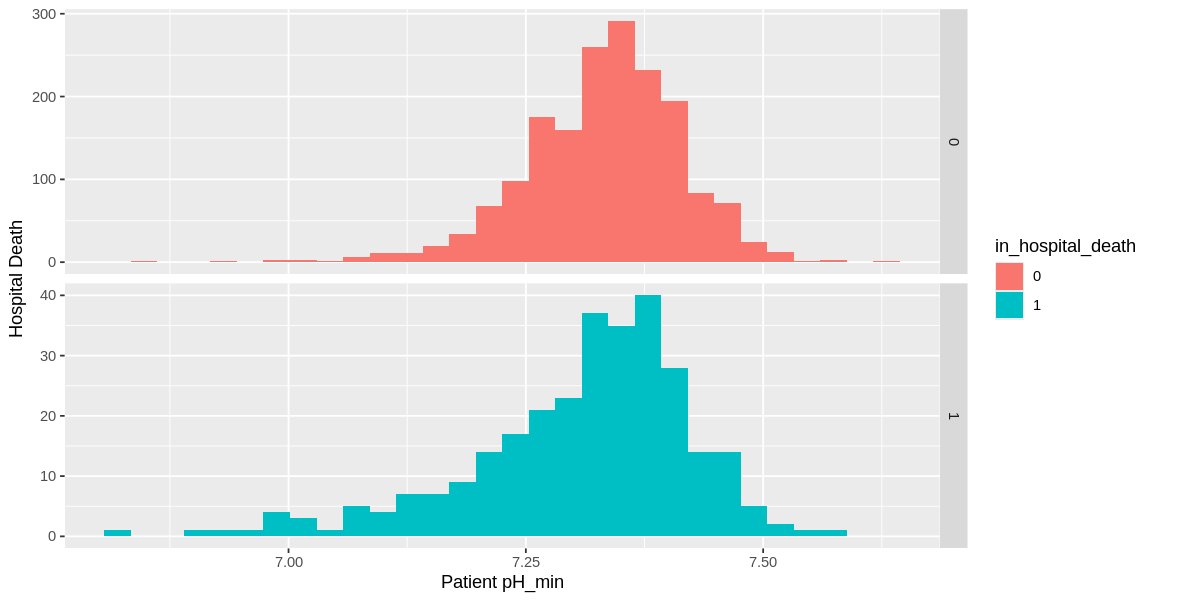

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


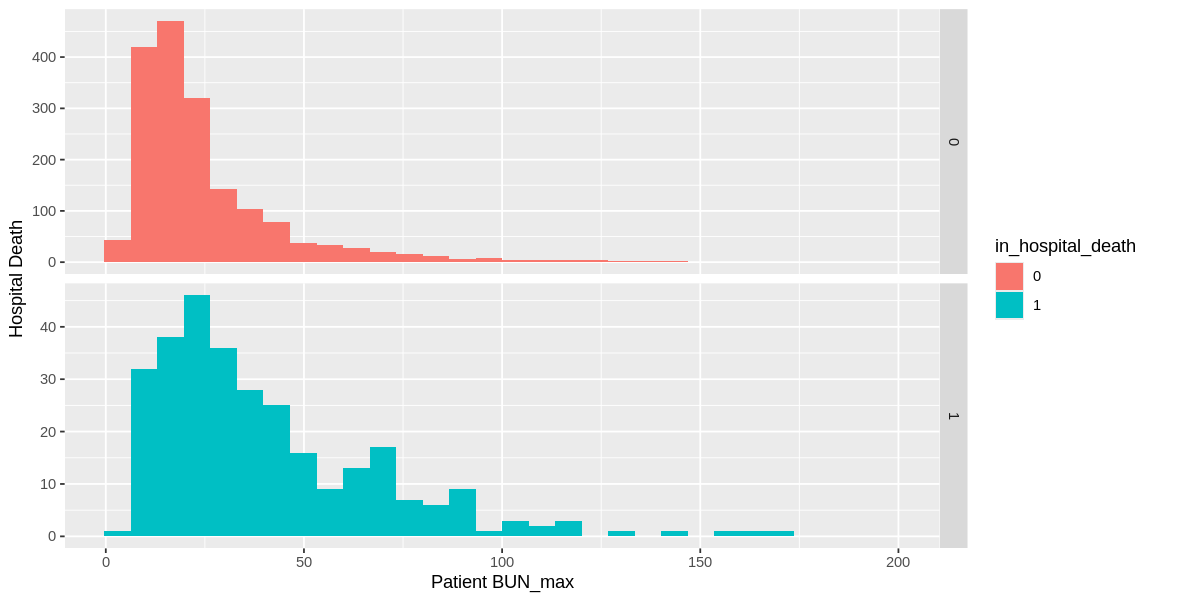

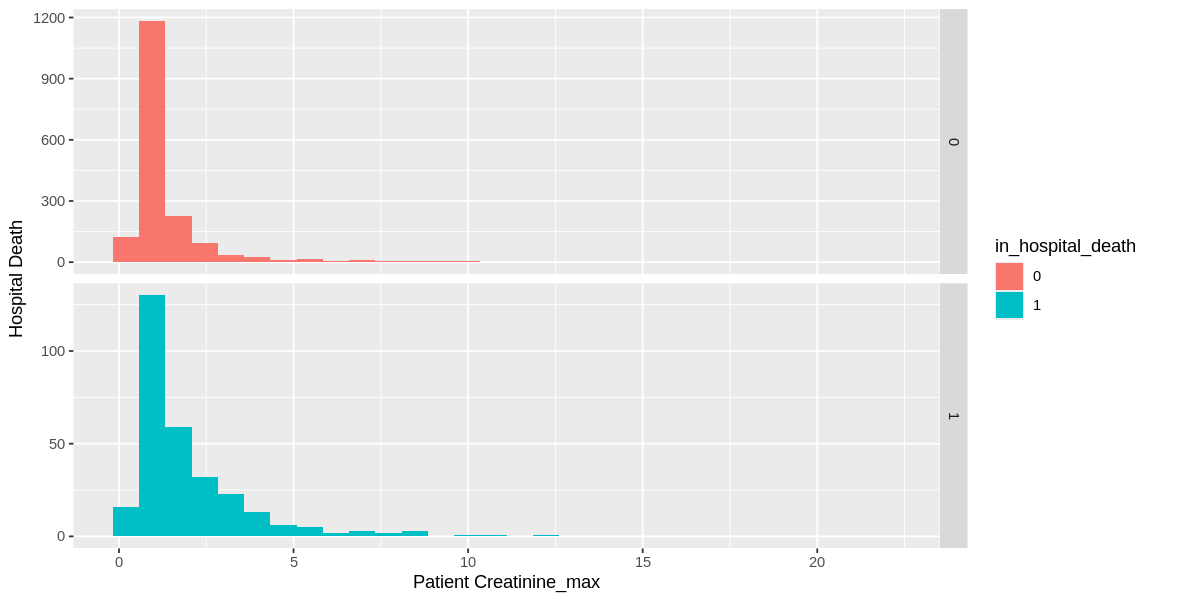

In [220]:
# Histograms of variables with notable differences across groups
ggplot(data=icu_patients_df1, aes(x=HCO3_min, fill=in_hospital_death)) + geom_histogram() + facet_grid(in_hospital_death ~ .,
       scales = "free") + labs(x="Patient HC03_min", y="Hospital Death")
ggplot(data=icu_patients_df1, aes(x=pH_min, fill=in_hospital_death)) + geom_histogram() + facet_grid(in_hospital_death ~ .,
       scales = "free") + labs(x="Patient pH_min", y="Hospital Death")
ggplot(data=icu_patients_df1, aes(x=BUN_max, fill=in_hospital_death)) + geom_histogram() + facet_grid(in_hospital_death ~ .,
       scales = "free") + labs(x="Patient BUN_max", y="Hospital Death")
ggplot(data=icu_patients_df1, aes(x=Creatinine_max, fill=in_hospital_death)) + geom_histogram() + facet_grid(in_hospital_death ~ .,
       scales = "free") + labs(x="Patient Creatinine_max", y="Hospital Death")

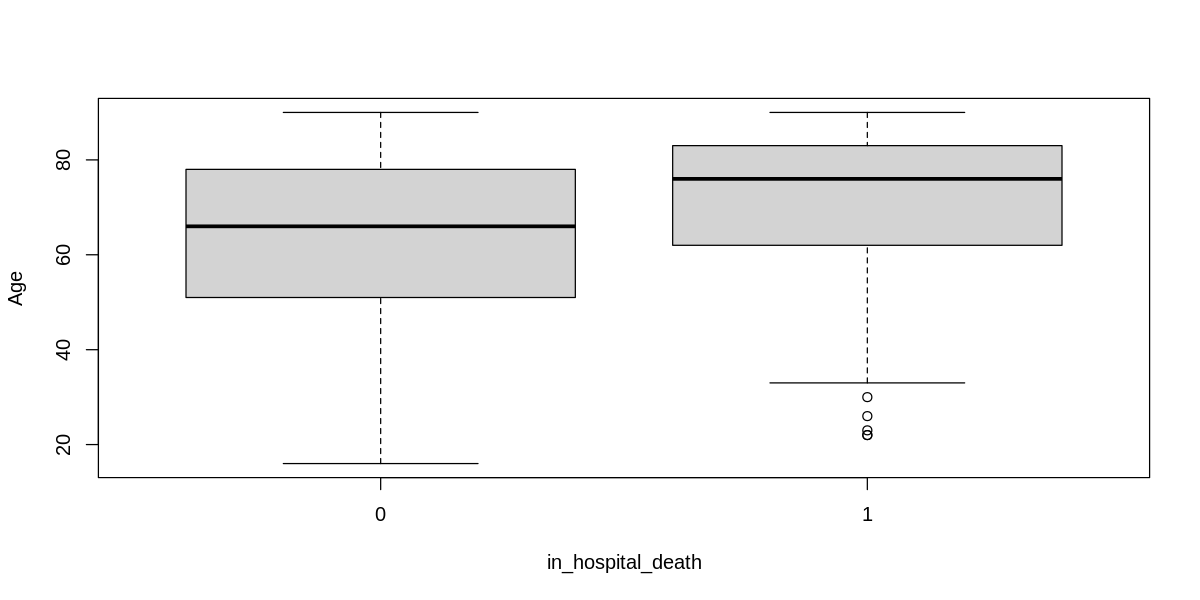

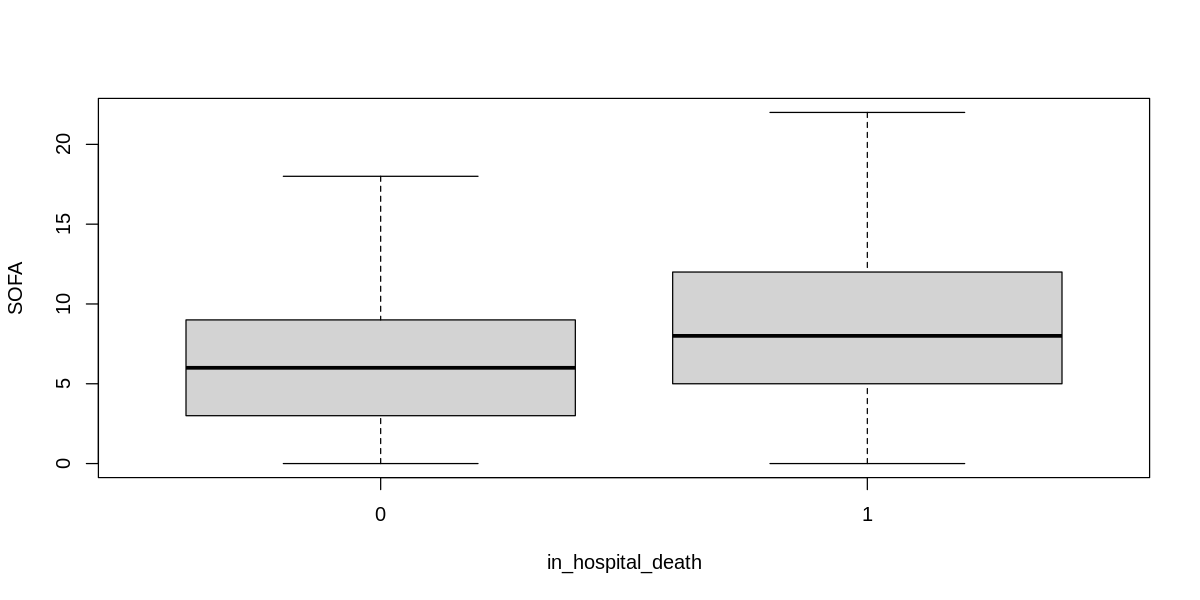

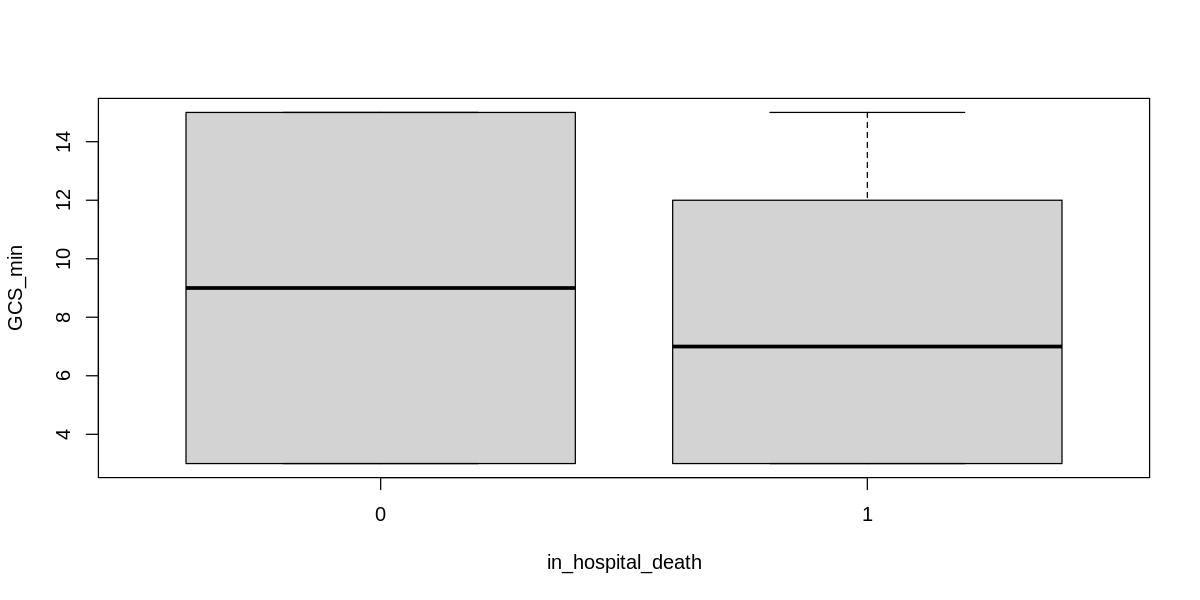

In [221]:
# Boxplots by outcome
plot(Age ~ in_hospital_death, data=icu_patients_df1)
plot(SOFA ~ in_hospital_death, data=icu_patients_df1)
plot(GCS_min ~ in_hospital_death, data=icu_patients_df1)

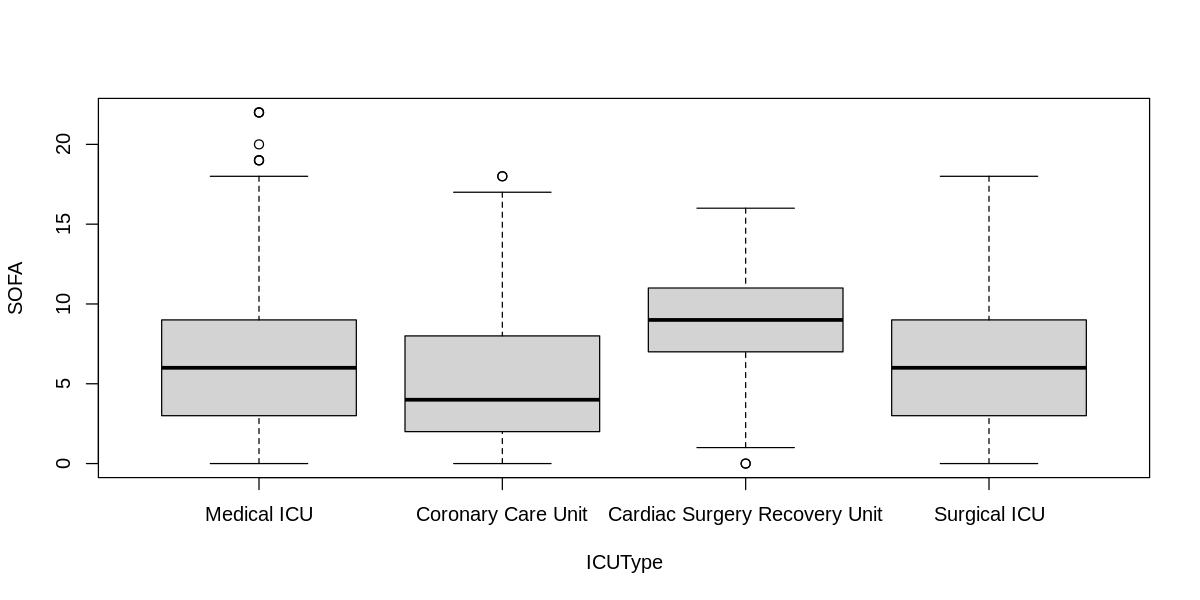

In [222]:
# SOFA by ICUtype groups
boxplot(SOFA ~ ICUType, data = icu_patients_df1)

`geom_smooth()` using formula = 'y ~ x'


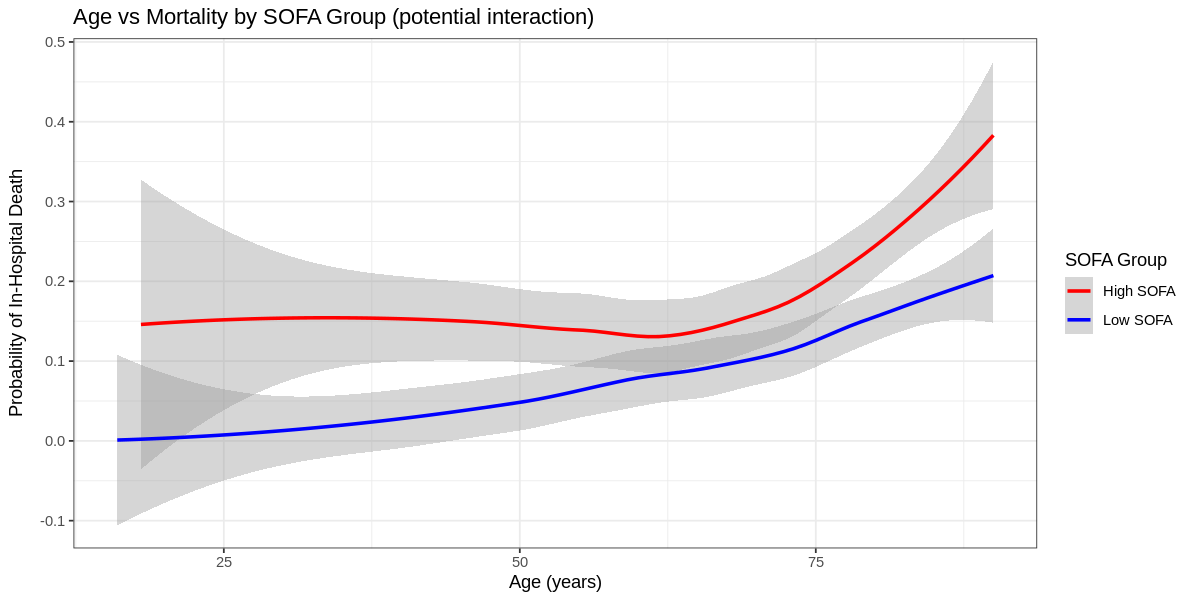

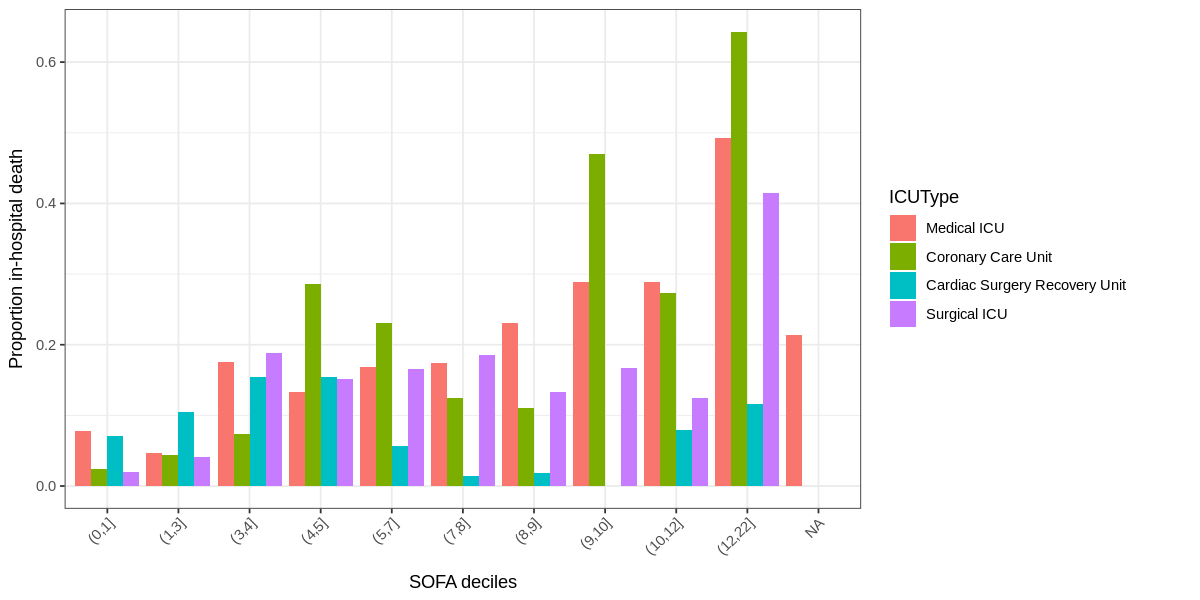

In [223]:
# Age x SOFA
icu_patients_df1 %>% filter(!is.na(SOFA)) %>% mutate(SOFA_group = ifelse(SOFA >=
  median(SOFA, na.rm=TRUE), "High SOFA", "Low SOFA")) %>%
  ggplot(aes(x = Age, y = as.numeric(as.character(in_hospital_death)), colour = SOFA_group)) +
  geom_smooth(method = "loess", se = TRUE) + scale_colour_manual(values = c("High SOFA" = "Red", "Low SOFA"  = "Blue")) + labs(x = "Age (years)",
  y = "Probability of In-Hospital Death", colour = "SOFA Group", title = "Age vs Mortality by SOFA Group (potential interaction)") + theme_bw()

# SOFA x ICUType
icu_patients_df1 %>% filter(!is.na(SOFA)) %>%
  mutate(SOFA_dec = cut(SOFA, unique(quantile(SOFA, seq(0, 1, by = 0.1))))) %>%
  group_by(SOFA_dec, ICUType) %>% summarise(mean = mean(as.numeric(as.character(in_hospital_death))),
  .groups = "drop") %>% ggplot(aes(SOFA_dec, mean, fill = ICUType)) + geom_col(position = "dodge") + labs(x = "SOFA deciles",
  y = "Proportion in-hospital death") + theme_bw() + theme(axis.text.x = element_text(angle = 45, hjust = 1))

**EDA**

Mortality was comparable between males (14.3%) and females (14.6%). Across ICU types, CSRU had the lowest mortality (5.8%) while Medical ICU, the largest group (n=788), had the highest (18.5%). Patients who died in the ICU are generally older and have higher SOFA scores (median age was 66 in survivors vs 76 in non-survivors; median SOFA was 6 vs 8 respectively). Interestingly, CSRU patients tend to have higher SOFA scores despite their lower mortality, likely reflecting transient post-surgical organ stress rather than uncontrolled critical illness.

GCS and SOFA (r=0.64), BUN_max and Creatinine_max (r=0.67), and SOFA and SAPS1 (r=0.68) are moderately correlated feature pairs. Looking at the histograms, BUN_max shows greater separation between survivors and non-survivors than Creatinine_max. Similarly, HCO3_min shows clearer distributional differences between outcome groups than its biological counterpart pH_min. Looking at the boxplots, GCS_min seems to be quite overlapping between the two target outcomes while SOFA's ranges appear more separated.

The smoothed probability curves show that the High SOFA group exhibits a notably steeper increase in mortality risk with age compared to the more gradual rise in the Low SOFA group, indicating that age and organ dysfunction severity interact. Older patients with high SOFA scores face disproportionately elevated mortality risk beyond what either factor predicts independently. Moreover, while mortality generally trends upward with SOFA deciles across all ICU types, the Coronary Care Unit exhibits a disproportionately higher proportion of deaths at the highest SOFA levels compared to other ICU types. Nevertheless, due to CCU having the smallest sample size, high mortality proportions in the upper deciles may be driven by a small number of high-acuity cardiac cases.

In [224]:
# Univariate tests
uni_vars <- c("Age", "ICUType", "Gender",  "GCS_min", "MAP_min", "Lactate_max",
              "Creatinine_max", "Urine_min", "Platelets_min", "Bilirubin_max",
              "Albumin_min", "BUN_max", "HCO3_min", "HR_max", "SOFA", "RespRate_max",
              "K_max", "pH_min", "HCT_min")

fit_univariate <- function(var, data) {
  model <- glm(as.formula(paste("in_hospital_death ~", var)), family = binomial,
            data = data)
  print(summary(model))}
for (v in uni_vars) {fit_univariate(v, icu_patients_df1)}


Call:
glm(formula = as.formula(paste("in_hospital_death ~", var)), 
    family = binomial, data = data)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -3.761624   0.303337 -12.401  < 2e-16 ***
Age          0.029376   0.004229   6.947 3.73e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1699.7  on 2060  degrees of freedom
Residual deviance: 1644.9  on 2059  degrees of freedom
AIC: 1648.9

Number of Fisher Scoring iterations: 5


Call:
glm(formula = as.formula(paste("in_hospital_death ~", var)), 
    family = binomial, data = data)

Coefficients:
                                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)                          -1.48098    0.09169 -16.152  < 2e-16 ***
ICUTypeCoronary Care Unit            -0.16527    0.18236  -0.906   0.3648    
ICUTypeCardiac Surgery Recovery Unit -1.30593    0.22189  -5.885 3.97e-09 *

**Univariate Analysis:** pH_min is dropped as it represents the same clinical construct as HC03. GCS_min and Creatinine_max are dropped as they are highly correlated with SOFA and BUN_max respectively. The retained counterparts are not only have stronger evidence in the literature but also apppear more visually separate aross the target outcome in the EDA. Platelets_min, MAP_min, and Gender are dropped for being non-significant during univariate screening. K_max and HCT_min are retained for now as they are borderline significant and have some evidence in the literature.

In [225]:
# M1: First multivariable model
logmod_m1 <- glm(in_hospital_death ~ Age + ICUType + Lactate_max + Urine_min + BUN_max
              + Bilirubin_max + Albumin_min + HCO3_min + HR_max + RespRate_max +
              SOFA + HCT_min + K_max, family = binomial, data = icu_patients_df1)
df1_task1 <- logmod_m1$model
print(drop1(logmod_m1, test = "Chisq"))

# Null model
logmod_null <- glm(in_hospital_death ~ 1, family = binomial, data = df1_task1)

Single term deletions

Model:
in_hospital_death ~ Age + ICUType + Lactate_max + Urine_min + 
    BUN_max + Bilirubin_max + Albumin_min + HCO3_min + HR_max + 
    RespRate_max + SOFA + HCT_min + K_max
              Df Deviance    AIC    LRT  Pr(>Chi)    
<none>             1392.9 1424.9                     
Age            1   1449.1 1479.1 56.156 6.695e-14 ***
ICUType        3   1437.2 1463.2 44.218 1.356e-09 ***
Lactate_max    1   1397.0 1427.0  4.046 0.0442766 *  
Urine_min      1   1394.3 1424.3  1.337 0.2475985    
BUN_max        1   1407.0 1437.0 14.101 0.0001733 ***
Bilirubin_max  1   1398.1 1428.1  5.160 0.0231106 *  
Albumin_min    1   1396.7 1426.7  3.761 0.0524693 .  
HCO3_min       1   1393.0 1423.0  0.035 0.8506967    
HR_max         1   1394.1 1424.1  1.172 0.2790696    
RespRate_max   1   1399.2 1429.2  6.292 0.0121297 *  
SOFA           1   1423.6 1453.6 30.646 3.097e-08 ***
HCT_min        1   1393.0 1423.0  0.023 0.8797601    
K_max          1   1394.3 1424.3  1.395 0.23

**Variable Selection:** Urine_min and HR_max are dropped as non-significant and captured within SOFA's renal and cardiovascular domains respectively. K_max and HCT_min are non-significant and also dropped, having only been borderline in univariate screening. HCO3_min is retained despite non-significance in the multivariable model given its univariate significance and established role in mortality literature. Albumin_min is retained as a likelihood ratio test confirmed its contribution to model fit (p = 0.038) with no AIC penalty.

In [226]:
# M2: Revised model
logmod_m2 <- glm(in_hospital_death ~ Age + ICUType + Lactate_max + Bilirubin_max
                   + Albumin_min + BUN_max + HCO3_min + RespRate_max + SOFA,
                   family = binomial, data = df1_task1)

In [227]:
# M3: SOFA:ICUType
logmod_m3 <- glm(in_hospital_death ~Age + ICUType + Lactate_max + Bilirubin_max
          + Albumin_min + BUN_max + HCO3_min + RespRate_max + SOFA +
           SOFA:ICUType, family = binomial, data = df1_task1)
# Final: SOFA:ICUType + Age:SOFA
logmod_final <- glm(in_hospital_death ~ Age + ICUType + Lactate_max + Bilirubin_max
            + Albumin_min + BUN_max +  HCO3_min + RespRate_max + SOFA + Age:SOFA
            + SOFA:ICUType, family = binomial, data = df1_task1)

In [228]:
# LRT
anova(logmod_null, logmod_m1, test = "Chisq"); anova(logmod_m2, logmod_m1, test = "Chisq")
anova(logmod_m2, logmod_m3, test = "Chisq"); anova(logmod_m3, logmod_final, test = "Chisq")

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1991,1660.299,NA,NA,NA
2,1976,1392.934,15,267.3652,3.244992e-48


,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1980,1396.780,NA,NA,NA
2,1976,1392.934,4,3.845525,0.4273152


,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1980,1396.780,NA,NA,NA
2,1977,1385.508,3,11.27169,0.0103439


,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1977,1385.508,NA,NA,NA
2,1976,1382.213,1,3.295326,0.06947732


In [229]:
model_comparison1 <- data.frame(
  Comparison = c("M1", "M2 (- 3 vars)", "M3 (+SOFA:ICUType)",
                 "Final (+SOFA:ICUType+Age:SOFA)"),
  Df = c(15, 4, 3, 1),
  LRT_p = c("<0.01 (vs null)", "0.427 (vs M1)", "0.010 (vs M2)", "0.069 (vs M3)"),
  AIC = c(round(AIC(logmod_m1), 2), round(AIC(logmod_m2), 2), round(AIC(logmod_m3), 2),
        round(AIC(logmod_final), 2)))
print(model_comparison1)

                      Comparison Df           LRT_p     AIC
1                             M1 15 <0.01 (vs null) 1424.93
2                  M2 (- 3 vars)  4   0.427 (vs M1) 1420.78
3             M3 (+SOFA:ICUType)  3   0.010 (vs M2) 1415.51
4 Final (+SOFA:ICUType+Age:SOFA)  1   0.069 (vs M3) 1414.21


**Interactions:** Adding SOFA:ICUType was highly significant (p = 0.010) and lowered AIC. Age:SOFA was non-significant when added to the base model (p = 0.14), but reached borderline significance when added alongside SOFA:ICUType (p = 0.069) with a marginal AIC reduction. Given the biological plausibility of age modifying the SOFA-mortality relationship (as observed in EDA), the interaction was retained.

This final model achieves the lowest AIC (1414.21) across all candidate models.

In [230]:
# Odds Ratios
print(round(cbind(OR = exp(coef(logmod_final)), exp(confint(logmod_final))), 3))

Waiting for profiling to be done...



                                             OR 2.5 % 97.5 %
(Intercept)                               0.002 0.000  0.009
Age                                       1.053 1.032  1.074
ICUTypeCoronary Care Unit                 0.380 0.153  0.882
ICUTypeCardiac Surgery Recovery Unit      0.883 0.238  2.846
ICUTypeSurgical ICU                       1.079 0.526  2.176
Lactate_max                               1.074 1.010  1.141
Bilirubin_max                             1.029 1.001  1.056
Albumin_min                               0.790 0.628  0.992
BUN_max                                   1.010 1.005  1.016
HCO3_min                                  1.002 0.972  1.034
RespRate_max                              1.024 1.006  1.042
SOFA                                      1.284 1.099  1.505
Age:SOFA                                  0.998 0.996  1.000
ICUTypeCoronary Care Unit:SOFA            1.126 1.019  1.252
ICUTypeCardiac Surgery Recovery Unit:SOFA 0.871 0.763  0.997
ICUTypeSurgical ICU:SOFA

In [231]:
# Median patients in Medical ICU and Cardiac Surgery Recovery Unit
pred_dat_medical <- data.frame(Age = 67, SOFA = 7, ICUType = "Medical ICU",
                   Lactate_max = 2.2, Bilirubin_max = 0.7, HCO3_min = 23,
                   BUN_max = 20, Albumin_min = 3, RespRate_max = 27)
pred_dat_csru <- pred_dat_medical; pred_dat_csru$ICUType <- "Cardiac Surgery Recovery Unit"
cat("Predicted probability - average Medical ICU patient:",
    round(predict(logmod_final, newdata = pred_dat_medical, type = "response"), 3), "\n")
cat("Predicted probability - average CSRU patient:       ",
    round(predict(logmod_final, newdata = pred_dat_csru,    type = "response"), 3), "\n")
cat("Relative risk (Medical vs CSRU):",
    round(predict(logmod_final, newdata = pred_dat_medical, type = "response") /
      predict(logmod_final, newdata = pred_dat_csru, type = "response"), 3), "\n")

Predicted probability - average Medical ICU patient: 0.131 
Predicted probability - average CSRU patient:        0.048 
Relative risk (Medical vs CSRU): 2.724 


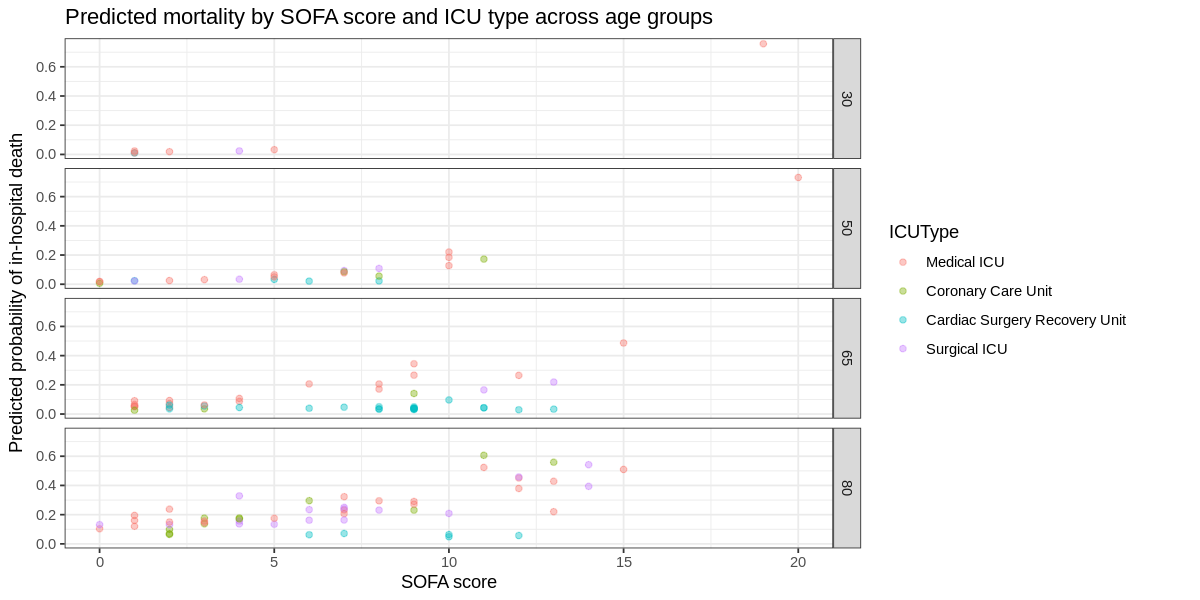

In [232]:
# Predicted probability of in-hospital death by SOFA and ICU types across age groups
df1_task1 %>% mutate(pred = predict(logmod_final, type = "response")) %>%
  filter(Age %in% c(30, 50, 65, 80)) %>%
  ggplot(aes(SOFA, pred)) + geom_point(aes(col = ICUType), alpha = 0.4) +
  facet_grid(rows = vars(Age)) +
  labs(y = "Predicted probability of in-hospital death", x = "SOFA score",
  title = "Predicted mortality by SOFA score and ICU type across age groups") + theme_bw()

In [233]:
# AUC and PseudoR2
predprob = predict(logmod_final, type="response")
performance(prediction(predprob, logmod_final$y), "auc")@y.values[[1]]
print(PseudoR2(logmod_final, which = "McFadden"))

[1] 0.7819964

 McFadden 
0.1674919 


**Model Interpretation**

The model achieves an AUC of 0.782, indicating good discriminative ability. This is consistent with a McFadden R² of 0.167, reflecting meaningful but not complete explanatory power, as expected for a complex clinical outcome with multiple contributing factors.

Among the clnical markers, holding all other variables constant, higher Lactate (OR 1.074, 95% CI 1.010–1.141), Bilirubin (OR 1.029, 95% CI 1.001–1.056), BUN (OR 1.010, 95% CI 1.005–1.016), and RespRate (OR 1.024, 95% CI 1.006–1.042) are each independently associated with increased mortality odds, while higher minimum Albumin is slightly protective (OR 0.790, 95% CI 0.628–0.992), reflecting its role as a marker of nutritional reserve. HCO3 was retained on clinical grounds but its odds ratio includes 1 and does not appear significant in the model (OR 1.002, 95% CI 0.972–1.034).

The effects of Age and SOFA on mortality are not independently interpretable as both appear in an interaction term. At lower SOFA scores the age effect is more pronounced, while at higher SOFA scores the additional mortality risk from each year of age is reduced (Age:SOFA OR 0.998, 95% CI 0.996–1.000). This is consistent with the EDA finding that mortality is concentrated among older patients with elevated SOFA, but that very high SOFA is itself strongly predictive regardless of age. Similarly, ICUType effects are modified by SOFA. Coronary Care Unit patients have a lower baseline odds of death compared to Medical ICU (OR 0.380), but their mortality risk increases more steeply with organ dysfunction severity (CCU:SOFA OR 1.126, 95% CI 1.019–1.252). Conversely, CSRU patients show a protective SOFA interaction (CSRU:SOFA OR 0.871, 95% CI 0.763–0.997). This makes sense as CSRU patients undergo planned surgical procedures where temporary organ stress (and thus, elevated markers) is an expected and managed part of recovery rather than a sign of uncontrolled critical illness. As such, elevated SOFA in CSRU reflects anticipated physiological disruption rather than true disease severity, and carries a weaker mortality signal than equivalent SOFA scores in Medical ICU patients. To illustrate the interaction clinically, a median Medical ICU patient has a predicted mortality probability of 13.1% compared to 4.8% for an equivalent CSRU patient (relative risk of 2.72). This highlights the substantial prognostic difference between ICU types beyond what SOFA alone captures.

The facet grid figure further illustrates these combined effects. At age 30, predicted mortality remains low across all ICU types regardless of SOFA score, reflecting the protective effect of younger age. By age 65 and especially age 80, predicted probabilities diverge substantially — Medical ICU patients with high SOFA scores approach 50–70% predicted mortality, while CSRU patients at equivalent SOFA scores remain considerably lower. This visualisation directly demonstrates how age and ICUType jointly moderate the SOFA-mortality relationship captured by the interaction terms.

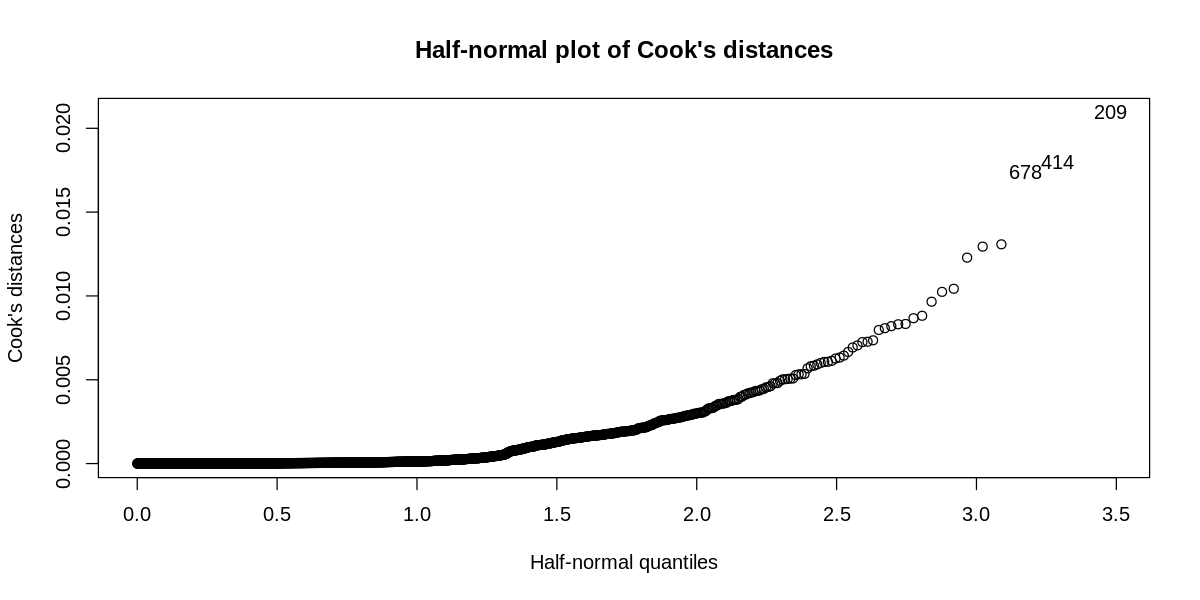

In [234]:
# Cook's Distance
cook <- cooks.distance(logmod_final)
faraway::halfnorm(cook, 3, ylab="Cook's distances",
                  main = "Half-normal plot of Cook's distances")

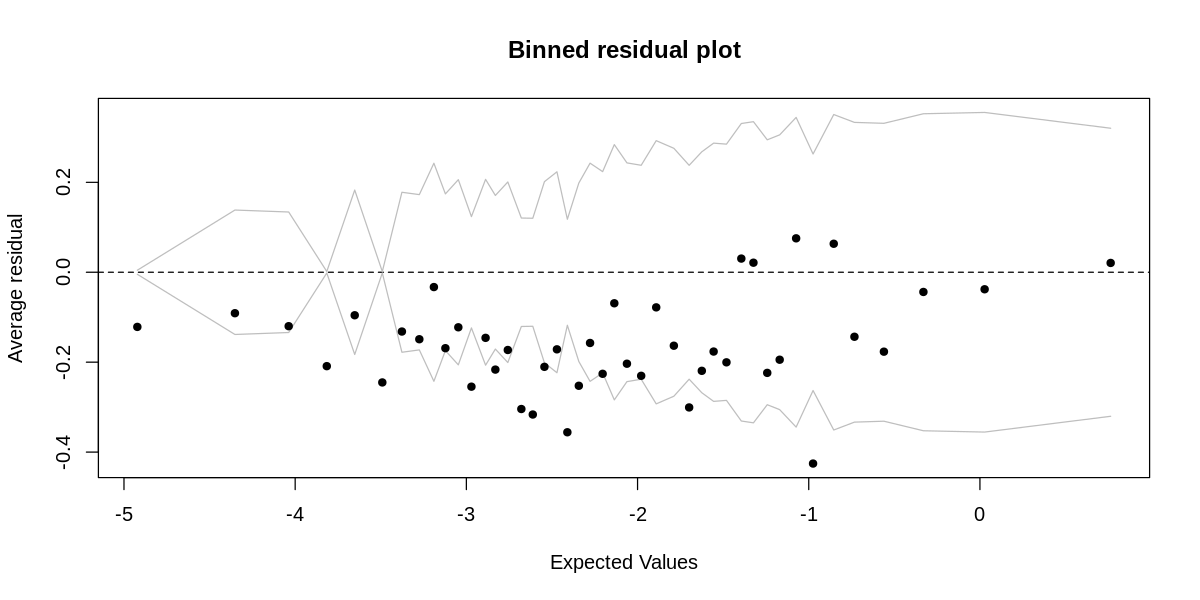

In [235]:
# Binned deviance residuals plot
binnedplot(predict(logmod_final), residuals(logmod_final))

HL_stat      df   p_val 
33.3830 49.0000  0.9569

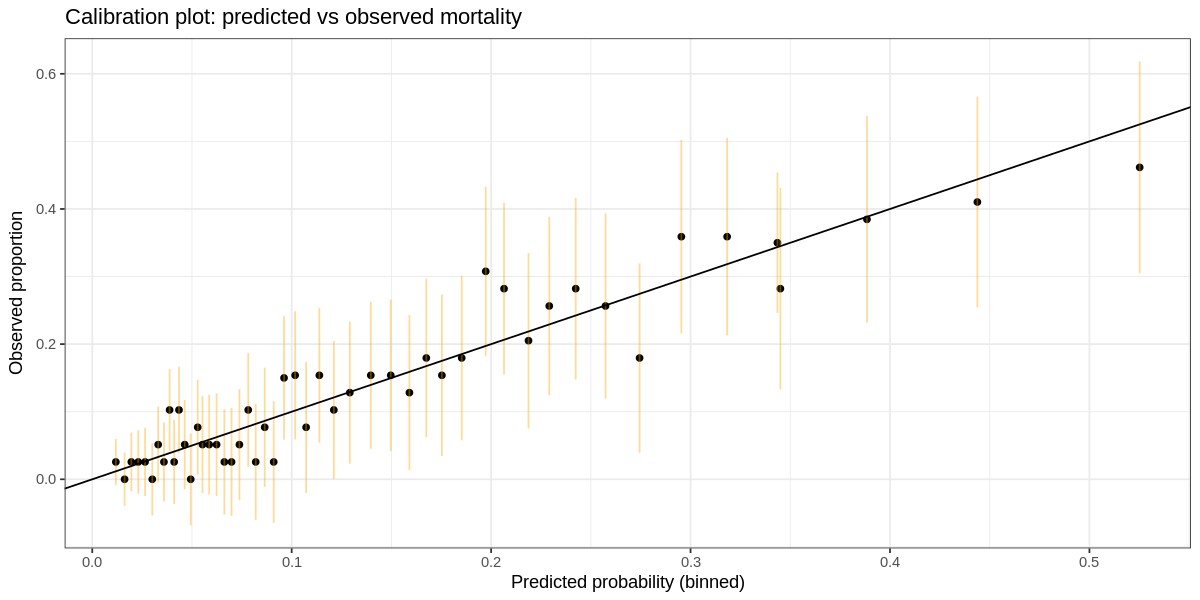

In [236]:
# Calibration plot + Hosmer-Lemeshow test
logmod_final$model %>%
  mutate(predprob = predict(logmod_final, type="response"),
  linpred  = predict(logmod_final),
  death_num = as.numeric(as.character(in_hospital_death))) %>%
  group_by(cut(linpred, breaks=unique(quantile(linpred, (1:50)/51)))) %>%
  summarise(obs_bin=sum(death_num), predprob_bin=mean(predprob), n_bin=n(), .groups="drop") %>%
  mutate(se=sqrt(predprob_bin*(1-predprob_bin)/n_bin)) -> hl_df

hl_df %>% ggplot(aes(predprob_bin, obs_bin/n_bin, ymin=obs_bin/n_bin-1.96*se, ymax=obs_bin/n_bin+1.96*se)) +
  geom_point() + geom_linerange(colour="orange", alpha=0.4) + geom_abline() +
  labs(x="Predicted probability (binned)", y="Observed proportion",
  title= "Calibration plot: predicted vs observed mortality") + theme_bw()

hl_stat <- with(hl_df, sum((obs_bin-n_bin*predprob_bin)^2/(n_bin*predprob_bin*(1-predprob_bin))))
c(HL_stat=round(hl_stat,3), df=nrow(hl_df)-1, p_val=round(1-pchisq(hl_stat, nrow(hl_df)-1),4))

In [237]:
#  Brier score
predprob <- predict(logmod_final, type = "response")
brier_final <- mean((predprob - logmod_final$y)^2)
brier_null <- mean((mean(logmod_final$y) - logmod_final$y)^2)
cat("Final model:", round(brier_final, 4), "\n")
cat("Null model: ", round(brier_null,  4), "\n")

Final model: 0.1057 
Null model:  0.1251 


In [238]:
# VIF
vif(logmod_final)

there are higher-order terms (interactions) in this model
consider setting type = 'predictor'; see ?vif



,GVIF,Df,GVIF^(1/(2*Df))
Age,5.047123,1,2.246580
ICUType,175.667110,3,2.366547
Lactate_max,1.261949,1,1.123365
Bilirubin_max,1.138379,1,1.066949
Albumin_min,1.114552,1,1.055724
BUN_max,1.249730,1,1.117913
HCO3_min,1.330703,1,1.153561
RespRate_max,1.115011,1,1.055941
SOFA,22.080402,1,4.698979
Age:SOFA,22.282558,1,4.720440


**Diagnostics**

Cook's distance was examined to assess influential observations. Three points exceeded 0.015, however, no values approached the conventional threshold of 1 and all represent real patients whose records were retained. Excluding them produced no meaningful change in model estimates. The binned residual plot shows the majority of points falling within the 95% confidence bounds, with some systematic negative residuals in the middle predicted probability range. This suggests mild misfit for patients with moderate predicted risk, though the overall pattern should be acceptable for a model of this complexity. The calibration plot shows acceptable agreement between predicted probabilities and observed proportions across the full risk range, with points closely tracking along the diagonal. The Hosmer-Lemeshow test confirms adequate calibration (HL statistic = 33.38, df = 49, p = 0.957), indicating no significant departure from calibration. The Brier score of 0.106 represents a 15% improvement over the null model Brier score of 0.125, indicating the model adds meaningful predictive value beyond the marginal outcome rate. Lastly, no multicollinearity issues were identified. The elevated GVIF for Age, SOFA, and ICUType are expected given their inclusion in interaction terms and do not indicate problematic collinearity among the main effects.

In [239]:
# Refiting on unimputed data
logmod_m0 <- glm(in_hospital_death ~ Age + SOFA + ICUType + Lactate_max + BUN_max
              + Albumin_min + HCO3_min + RespRate_max + Age:SOFA + SOFA:ICUType,
              family = binomial, data = icu_patients_df0)

In [240]:
# Coefficients in df0
print(round(cbind(OR_0 = exp(coef(logmod_m0)), exp(confint(logmod_m0))), 3))

Waiting for profiling to be done...



                                   OR_0 2.5 %        97.5 %
(Intercept)                       0.004 0.000  7.519749e+06
Age                               1.080 0.811  1.575000e+00
SOFA                              0.888 0.054  1.848600e+01
ICUTypeCoronary Care Unit      1268.592 0.006  6.105167e+08
ICUTypeSurgical ICU               0.000 0.000 3.126707e+126
Lactate_max                       1.645 1.060  2.927000e+00
BUN_max                           1.050 0.992  1.135000e+00
Albumin_min                       0.033 0.000  7.020000e-01
HCO3_min                          1.225 0.942  1.699000e+00
RespRate_max                      0.960 0.788  1.139000e+00
Age:SOFA                          1.003 0.963  1.043000e+00
SOFA:ICUTypeCoronary Care Unit    0.619 0.058  1.048300e+01
SOFA:ICUTypeSurgical ICU          0.403 0.000  1.750461e+35


**Refit (df0):** Refitting the final model on the unimputed dataset (df0) resulted in only 58 complete cases after listwise deletion, which is a substantial reduction. This is driven by the high missingness in variables such as Bilirubin_max (not estimable in df0) and the complete absence of CSRU patients with fully observed records, causing ICUTypeCardiac Surgery Recovery Unit to be dropped altogether. This degree of missingness is expected in unimputed clinical data and confirms that imputation necessary for stable estimation. The near-complete loss of observations means the df0 model is severely underpowered and its estimates should be interpreted with extreme caution. The model produces highly unstable coefficient estimates with enormous standard errors and confidence intervals spanning several orders of magnitude, particularly for ICUType and its SOFA interactions. Only Lactate_max retains statistical significance (OR 1.645, p = 0.041), while previously significant predictors including Age, SOFA, BUN, Albumin, and RespRate lose significance entirely. The AIC of 53.4 is not comparable to the imputed model given the vastly different analytical sample. Overall, the df0 refit demonstrates that the unimputed data is too sparse for reliable multivariable estimation.

**Conclusion**

The final model identifies a clinically coherent set of predictors of in-hospital mortality. Age and SOFA score are the dominant risk factors, with their interaction revealing that severity of organ dysfunction compounds mortality risk more steeply in older patients. Among biochemical markers, elevated Lactate, Bilirubin, BUN, and RespRate independently increase mortality odds, while higher minimum Albumin is protective. ICU type meaningfully modifies the SOFA-mortality relationship, with Medical ICU patients facing substantially higher predicted mortality than equivalent CSRU patients. This finding is consistent with the distinct clinical trajectories of patients with acute medical admissions compared to those undergoing planned surgery.

---

# **Predictive model: survival time after ICU admission**
For the survival analysis, SAPS1 is preferred over SOFA as the composite score. Composite scores are parsimonious in predictive frameworks where the priority is overall discrimination, and SAPS1 was designed specifically to predict ICU mortality from admission-window data (Le Gall et al., 1984). SOFA, as an organ-failure tracking tool rather than a mortality prediction instrument, is only a proxy of survival outcome and therefore less suited to a predictive task (Ferreira et al., 2001).

*Note: Age, BUN, GCS, HCT, HR, HCO3, K, RespRate, and Urine overlap with SAPS1 component variables. However, SAPS1 encodes these categorically whereas continuous measures may capture finer prognostic gradients. As these variables are also individually prominent in the ICU survival literature, they were retained for univariate screening.*

Iterations: relative error in phi-hat = 1e-04 
phi= 1.535954   sv2= 0.4023835   df= 11.82595   lambda= 3.817139 
phi= 1.466862   sv2= 0.5623238   df= 14.53638   lambda= 2.608571 
phi= 1.450554   sv2= 0.624506   df= 15.74609   lambda= 2.322723 
phi= 1.446604   sv2= 0.6430843   df= 16.12936   lambda= 2.249479 
phi= 1.44559   sv2= 0.6481785   df= 16.23629   lambda= 2.230234 
phi= 1.445323   sv2= 0.6495421   df= 16.26504   lambda= 2.225141 
phi= 1.445252   sv2= 0.6499046   df= 16.2727   lambda= 2.223791 
phi= 1.445233   sv2= 0.6500009   df= 16.27473   lambda= 2.223433 
phi= 1.445228   sv2= 0.6500264   df= 16.27527   lambda= 2.223338 


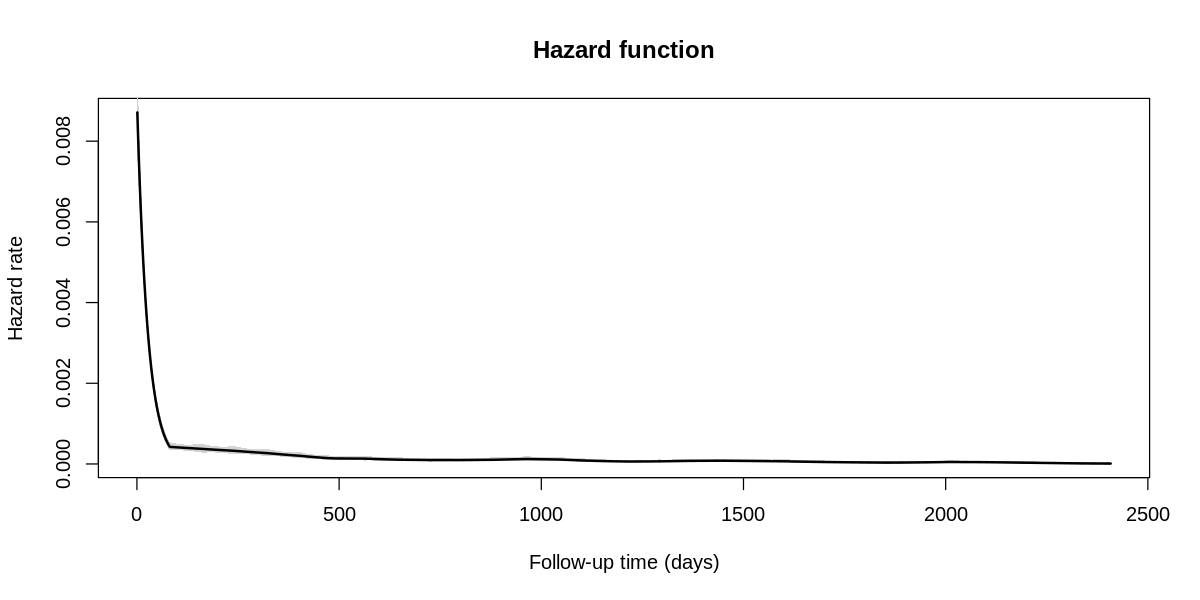

In [241]:
# Hazard function
plot(bshazard(Surv(Days, Status) ~ 1, data = icu_patients_df1), main = "Hazard function", xlab = "Follow-up time (days)")

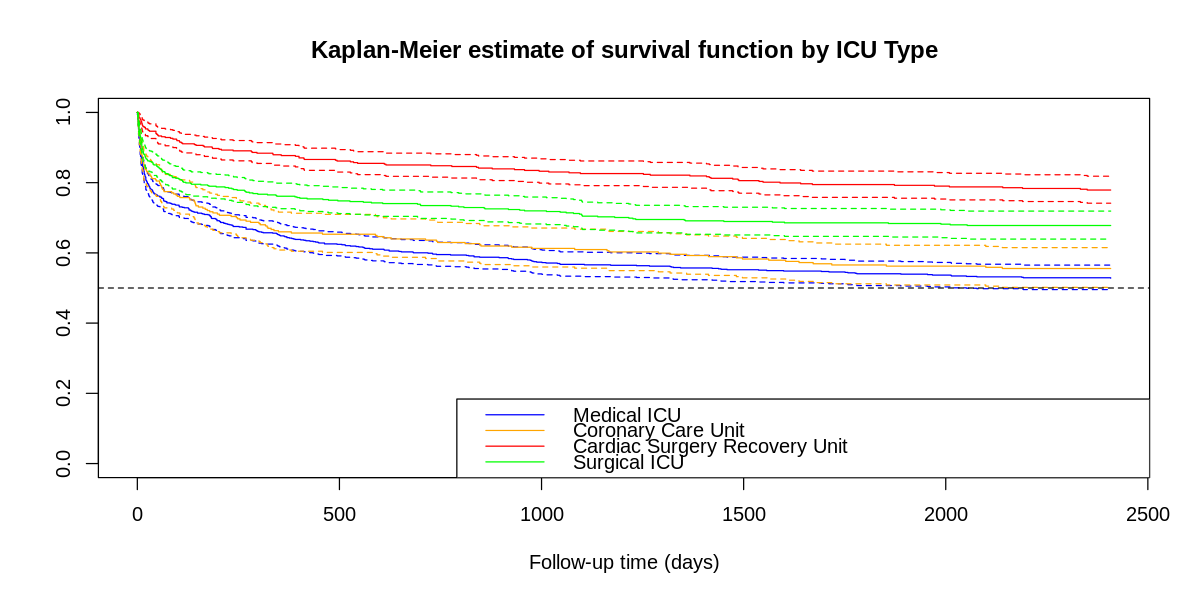

In [242]:
# Kaplan-Meier by ICUType
fitted_icu <- survfit(Surv(Days, Status) ~ ICUType, data = icu_patients_df1)
plot(fitted_icu, main = "Kaplan-Meier estimate of survival function by ICU Type", col = c("blue", "orange", "red", "green"),  conf.int = TRUE, xlab = "Follow-up time (days)")
legend("bottomright", levels(icu_patients_df1$ICUType), col = c("blue", "orange", "red", "green"), lty = 1)
abline(h = 0.5, lty = 2)

Call:
survdiff(formula = Surv(Days, Status) ~ ICUType, data = df_task2_age)

                                        N Observed Expected (O-E)^2/E (O-E)^2/V
ICUType=Medical ICU                   788      372      273     36.31     56.36
ICUType=Coronary Care Unit            297      132      106      6.31      7.34
ICUType=Cardiac Surgery Recovery Unit 448       99      191     44.37     59.23
ICUType=Surgical ICU                  528      170      203      5.45      7.42

 Chisq= 93  on 3 degrees of freedom, p= <2e-16 

Call:
survdiff(formula = Surv(Days, Status) ~ Age_hi, data = df_task2_age)

               N Observed Expected (O-E)^2/E (O-E)^2/V
Age_hi=High 1052      521      362      70.2       133
Age_hi=Low  1009      252      411      61.7       133

 Chisq= 133  on 1 degrees of freedom, p= <2e-16 

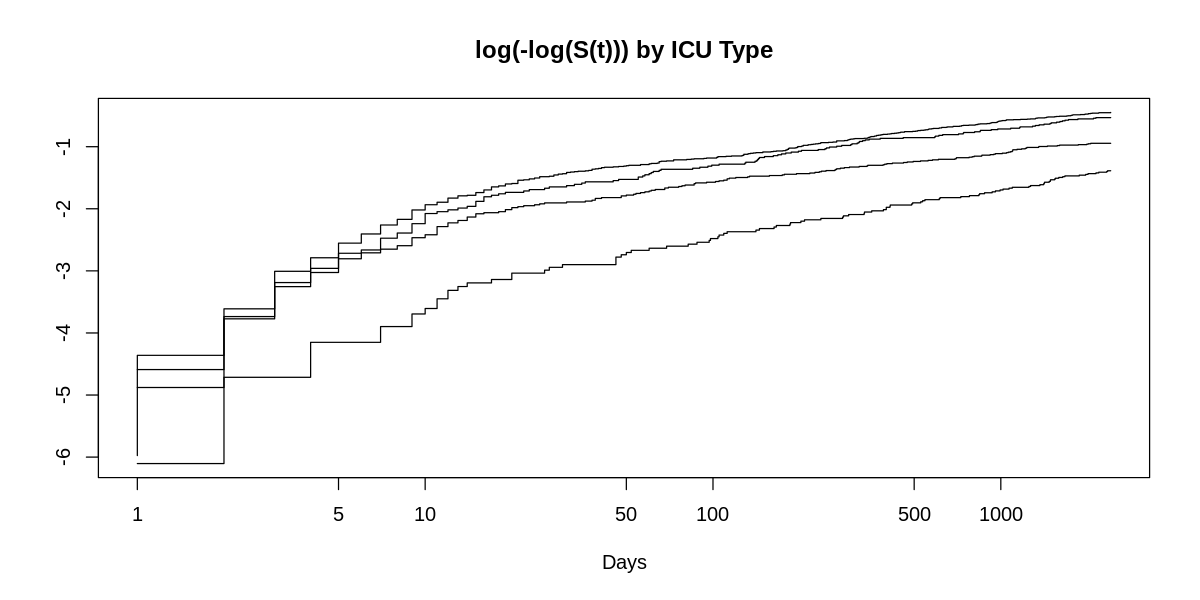

In [243]:
df_task2_age <- icu_patients_df1 %>%
  mutate(Age_hi = ifelse(Age >= median(Age, na.rm=TRUE), "High", "Low"))
# PH assumption: ICUType
fitbyicu <- survfit(Surv(Days, Status) ~ ICUType, data=df_task2_age)
plot(fitbyicu, fun="cloglog", main="log(-log(S(t))) by ICU Type", xlab="Days")
survdiff(Surv(Days, Status) ~ ICUType, data=df_task2_age)
# PH assumption: Age
survdiff(Surv(Days, Status) ~ Age_hi, data=df_task2_age)

**EDA**

Median survival cannot be estimated as fewer than 50% of patients died during follow-up, reflecting the high censoring rate (62.5%). This indicates that the majority of patients survived beyond the observation window, and survival analyses must account for this censoring rather than treating these patients as survivors.

The hazard function shows a sharp decline from a high initial rate in the first ~30 days, flattening to near zero beyond approximately 100 days. This early concentration of mortality risk reflects the acute nature of ICU admission as patients who survive the initial critical period face substantially lower ongoing hazard. The Kaplan-Meier curves by ICU type reveal substantially different survival trajectories (log-rank χ² = 93, df = 3, p < 0.001). CSRU patients have the highest long-term survival, consistent with their planned surgical admissions and transient organ stress. Medical ICU patients show the steepest early decline, with survival probability approaching 50% over the follow-up period.

Both ICUType and Age are strongly associated with survival time (ICUType: χ² = 93, p < 0.001; Age dichotomised at median: χ² = 133, df = 1, p < 0.001). The log-log plot by ICUType shows non-parallel lines, indicating potential PH violation. This motivates testing for interactions within these terms.

In [244]:
# Univariate tests
uni_vars_t2 <- c("SAPS1", "Age", "ICUType", "Gender", "Albumin_min", "BUN_max",
                 "Creatinine_max", "Bilirubin_max", "Platelets_min", "HCT_min",
                 "GCS_min", "HR_max", "Lactate_max", "pH_min", "MAP_min", "K_max",
                 "RespRate_max", "HCO3_min", "Urine_min")
for (v in uni_vars_t2) {
  model   <- coxph(as.formula(paste("Surv(Days, Status) ~", v)), data = icu_patients_df1)
  print(summary(model))}

Call:
coxph(formula = as.formula(paste("Surv(Days, Status) ~", v)), 
    data = icu_patients_df1)

  n= 1965, number of events= 741 
   (96 observations deleted due to missingness)

          coef exp(coef) se(coef)     z Pr(>|z|)    
SAPS1 0.068992  1.071428 0.007256 9.508   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

      exp(coef) exp(-coef) lower .95 upper .95
SAPS1     1.071     0.9333     1.056     1.087

Concordance= 0.603  (se = 0.01 )
Likelihood ratio test= 91.03  on 1 df,   p=<2e-16
Wald test            = 90.41  on 1 df,   p=<2e-16
Score (logrank) test = 90.97  on 1 df,   p=<2e-16

Call:
coxph(formula = as.formula(paste("Surv(Days, Status) ~", v)), 
    data = icu_patients_df1)

  n= 2061, number of events= 773 

       coef exp(coef) se(coef)     z Pr(>|z|)    
Age 0.03355   1.03412  0.00250 13.42   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

    exp(coef) exp(-coef) lower .95 upper .95
Age     1.034     

**Univariate Analysis**: Platelets_min, GCS_min, HR_max, and HCT_min were dropped as non-significant in univariate screening. Gender was borderline (p=0.05) and carried forward to multivariable modelling.

In [245]:
df1_task2 <- icu_patients_df1[
  complete.cases(icu_patients_df1[, c("SAPS1", "MAP_min", "RespRate_max", "K_max")]),]
# M1: Full multivariable model
cox_m1 <- coxph(Surv(Days, Status) ~ SAPS1 + Age + ICUType + BUN_max + Creatinine_max
          + Albumin_min + Bilirubin_max + Lactate_max + MAP_min + Urine_min +
           K_max + RespRate_max + HCO3_min + Gender, data = df1_task2)
print(drop1(cox_m1, test = "Chisq"))

Single term deletions

Model:
Surv(Days, Status) ~ SAPS1 + Age + ICUType + BUN_max + Creatinine_max + 
    Albumin_min + Bilirubin_max + Lactate_max + MAP_min + Urine_min + 
    K_max + RespRate_max + HCO3_min + Gender
               Df   AIC     LRT  Pr(>Chi)    
<none>            10371                      
SAPS1           1 10403  33.483 7.189e-09 ***
Age             1 10482 112.448 < 2.2e-16 ***
ICUType         3 10457  92.090 < 2.2e-16 ***
BUN_max         1 10399  29.675 5.109e-08 ***
Creatinine_max  1 10371   1.959   0.16160    
Albumin_min     1 10372   2.994   0.08358 .  
Bilirubin_max   1 10373   3.573   0.05873 .  
Lactate_max     1 10374   5.052   0.02460 *  
MAP_min         1 10370   0.510   0.47530    
Urine_min       1 10371   1.448   0.22880    
K_max           1 10369   0.003   0.95367    
RespRate_max    1 10375   5.504   0.01898 *  
HCO3_min        1 10376   6.539   0.01055 *  
Gender          1 10369   0.046   0.82941    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘

In [246]:
# M2 (-5 vars) and M3 (-7 vars)
cox_m2 <- coxph(Surv(Days, Status) ~ RespRate_max + HCO3_min + SAPS1 + Age + ICUType
            + BUN_max + Albumin_min + Bilirubin_max  + Lactate_max, data = df1_task2)
cox_m3 <- coxph(Surv(Days, Status) ~ RespRate_max + HCO3_min + SAPS1 + Age + ICUType
            + BUN_max + Lactate_max, data = df1_task2)

**Feature Selection:** MAP_min, Urine_min, K_max, Gender, and Creatinine_max were subsequently dropped as they are non-significant in the multivariable model. Albumin_min and Bilirubin_max were retained despite borderline significance as dropping either significantly worsened model fit (LRT p < 0.05) and increased AIC.

In [247]:
# M4: Adding interaction term
cox_int <- coxph(Surv(Days, Status) ~ SAPS1 + Age + ICUType + BUN_max + Albumin_min +
           Bilirubin_max + Lactate_max + RespRate_max + HCO3_min + Age:ICUType,
           data = df1_task2)

**Interaction term:** The Age:ICUType interaction term was retained as it significantly improved concordance (0.722 → 0.726) and model fit (p < 0.01). SAPS1:ICUType was non-significant (p = 0.178) and excluded.

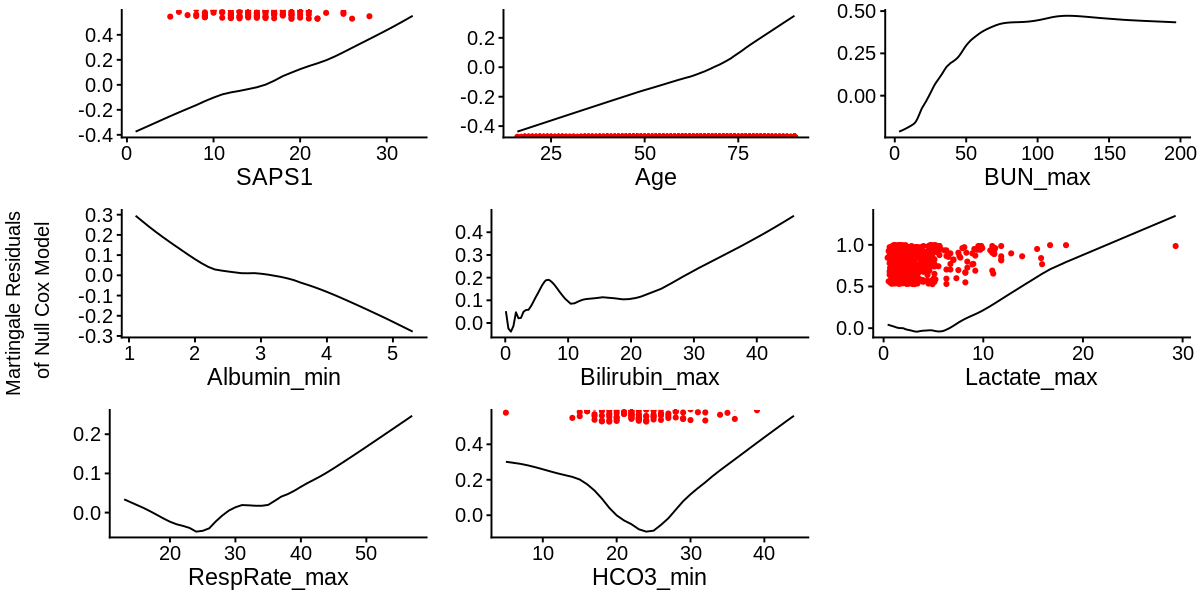

In [248]:
# Functional form check of continuous vars
ggcoxfunctional(Surv(Days, Status) ~ SAPS1 + Age + BUN_max + Albumin_min +
  Bilirubin_max + Lactate_max + RespRate_max + HCO3_min, data = df1_task2)

In [249]:
# M5: Adding quadratic term
cox_quad <- coxph(Surv(Days, Status) ~ SAPS1 + Age + ICUType + BUN_max + I(BUN_max^2)
          + Albumin_min + Bilirubin_max + Lactate_max + RespRate_max + HCO3_min
          + Age:ICUType, data = df1_task2)

**Quadratic term**: BUN_max exhibited a nonlinear relationship with survival — risk increases steeply at lower values before plateauing at higher concentrations. A quadratic term significantly improved model fit (LRT p < 0.05) and was retained. Quadratic terms for HCO3 and RespRate were tested but non-significant and excluded.



In [250]:
# Time-splitting approach: Sensitivity Analysis
cox_strata <- coxph(Surv(tstart, Days, Status) ~  SAPS1:strata(tgroup) + Age + ICUType
              + BUN_max + I(BUN_max^2) +  Albumin_min:strata(tgroup)
              + Bilirubin_max:strata(tgroup) + Lactate_max:strata(tgroup) +
               RespRate_max:strata(tgroup) + HCO3_min:strata(tgroup) + Age:ICUType,
                data = survSplit(Surv(Days, Status) ~ .,
                data = df1_task2, cut = c(20), episode = "tgroup",id = "id2"))
cox.zph(cox_strata)

                               chisq df     p
Age                           0.4110  1 0.521
ICUType                       9.9973  3 0.019
BUN_max                       1.2184  1 0.270
I(BUN_max^2)                  0.0423  1 0.837
SAPS1:strata(tgroup)          4.8434  2 0.089
strata(tgroup):Albumin_min    0.8723  2 0.647
strata(tgroup):Bilirubin_max  7.2632  2 0.026
strata(tgroup):Lactate_max    4.3681  2 0.113
strata(tgroup):RespRate_max   0.0807  2 0.960
strata(tgroup):HCO3_min       4.4487  2 0.108
Age:ICUType                  10.6424  3 0.014
GLOBAL                       34.0424 21 0.036

**Resolving PH Violations**: The time-splitting approach at day 20 successfully resolved the majority of proportional hazards violations, with the global Schoenfeld test improving from p < 0.001 in the prior models to p = 0.036. In cox_quad, most predictors violated PH assumptions, with only Age satisfying the assumption individually. This is likely because SAPS1 and the other clinical measures are all acute admission markers, and thus, their prognostic value is inherently strongest in the first days and diminishes as patients either die early or stabilise. The PH violation observed consequently reflects real biological properties as these variables naturally have time-varying effects. The cut point of 20 days applied in the sensitivity analysis likely reflects this critical early window of ICU mortality risk where the majority of deaths are concentrated, as also seen in the hazard function. The time-split model achieves the highest concordance (0.734) and lowest AIC (10312.85) across all models considered. However, ICUType and Age:ICUType violations persisted after time-splitting (p = 0.019 and p = 0.014 respectively). Bilirubin_max also retained a borderline violation (p = 0.026) within its stratified term.

In [251]:
# Check PH violations
cox.zph(cox_m1); cox.zph(cox_m2); cox.zph(cox_m3); cox.zph(cox_int); cox.zph(cox_quad)
anova(cox_m2, cox_m1); anova(cox_m3, cox_m2); anova(cox_m2, cox_int); anova(cox_int, cox_quad)

                chisq df       p
SAPS1          21.343  1 3.8e-06
Age             1.317  1 0.25109
ICUType        10.359  3 0.01575
BUN_max         2.934  1 0.08676
Creatinine_max  1.443  1 0.22961
Albumin_min     8.847  1 0.00294
Bilirubin_max  11.937  1 0.00055
Lactate_max    28.991  1 7.3e-08
MAP_min         0.253  1 0.61508
Urine_min       1.747  1 0.18625
K_max           0.383  1 0.53593
RespRate_max    5.203  1 0.02255
HCO3_min       28.849  1 7.8e-08
Gender          0.209  1 0.64762
GLOBAL         74.792 16 1.4e-09

              chisq df       p
RespRate_max   5.26  1 0.02187
HCO3_min      28.60  1 8.9e-08
SAPS1         21.14  1 4.3e-06
Age            1.36  1 0.24331
ICUType       10.48  3 0.01492
BUN_max        3.45  1 0.06322
Albumin_min    8.72  1 0.00315
Bilirubin_max 12.42  1 0.00042
Lactate_max   28.90  1 7.6e-08
GLOBAL        71.62 11 6.0e-11

             chisq df       p
RespRate_max  5.47  1   0.019
HCO3_min     28.43  1 9.7e-08
SAPS1        20.45  1 6.1e-06
Age           1.51  1   0.219
ICUType      10.67  3   0.014
BUN_max       3.42  1   0.064
Lactate_max  27.74  1 1.4e-07
GLOBAL       61.85  9 5.9e-10

              chisq df       p
SAPS1         21.33  1 3.9e-06
Age            1.21  1 0.27047
ICUType        9.90  3 0.01939
BUN_max        3.86  1 0.04938
Albumin_min    8.74  1 0.00312
Bilirubin_max 12.19  1 0.00048
Lactate_max   28.60  1 8.9e-08
RespRate_max   5.48  1 0.01929
HCO3_min      28.90  1 7.6e-08
Age:ICUType   10.64  3 0.01383
GLOBAL        73.07 14 5.3e-10

              chisq df       p
SAPS1         21.36  1 3.8e-06
Age            1.07  1 0.30099
ICUType       10.20  3 0.01695
BUN_max        5.31  1 0.02116
I(BUN_max^2)   1.49  1 0.22174
Albumin_min    9.10  1 0.00255
Bilirubin_max 12.27  1 0.00046
Lactate_max   28.24  1 1.1e-07
RespRate_max   5.19  1 0.02269
HCO3_min      29.42  1 5.8e-08
Age:ICUType   10.94  3 0.01207
GLOBAL        77.29 15 2.2e-10

,loglik,Chisq,Df,Pr(>|Chi|)
,<dbl>,<dbl>,<int>,<dbl>
1,-5171.755,NA,NA,NA
2,-5169.652,4.205413,5,0.5202366


,loglik,Chisq,Df,Pr(>|Chi|)
,<dbl>,<dbl>,<int>,<dbl>
1,-5175.489,NA,NA,NA
2,-5171.755,7.467808,2,0.02389935


,loglik,Chisq,Df,Pr(>|Chi|)
,<dbl>,<dbl>,<int>,<dbl>
1,-5171.755,NA,NA,NA
2,-5163.864,15.78258,3,0.001256508


,loglik,Chisq,Df,Pr(>|Chi|)
,<dbl>,<dbl>,<int>,<dbl>
1,-5163.864,NA,NA,NA
2,-5159.908,7.910996,1,0.004913522


In [252]:
model_comparison2 <- data.frame(
  Model = c("M1", "M2", "M3", "M4 (interaction)", "Final (quadratic)", "M6 (time-split)"),
  Predictors = c(14, 9, 7, 10, 11, 11),
  AIC = c(AIC(cox_m1), AIC(cox_m2), AIC(cox_m3), AIC(cox_int), AIC(cox_quad),
         AIC(cox_strata)),
  Concordance = c(0.722, 0.722, 0.720, 0.726, 0.727, 0.734),
  LRT_p = c("-", "0.52 (vs M1)", "0.02 (vs M2)", "<0.01 (vs M2)", "<0.01 (vs M4)", "-"),
  "PH Global p" = c("1.4e-09", "6.0e-11", "5.9e-10", "5.3e-10", "2.2e-10", "0.036"))
print(model_comparison2)
cat("Max log-likelihood:", cox_final$loglik[2])

              Model Predictors      AIC Concordance         LRT_p PH.Global.p
1                M1         14 10371.30       0.722             -     1.4e-09
2                M2          9 10365.51       0.722  0.52 (vs M1)     6.0e-11
3                M3          7 10368.98       0.720  0.02 (vs M2)     5.9e-10
4  M4 (interaction)         10 10355.73       0.726 <0.01 (vs M2)     5.3e-10
5 Final (quadratic)         11 10349.82       0.727 <0.01 (vs M4)     2.2e-10
6   M6 (time-split)         11 10312.85       0.734             -       0.036
Max log-likelihood: -5159.908

Despite its superior fit, the time-split model was not selected as the final model for evaluation and prediction. Stratifying on time restructures the data, preventing standard individual-level predicted survival curves via survfit(). As the primary goal is prediction of individual patient survival trajectories, M5 (cox_quad) was retained as the final model (the time-split approach is reported as a sensitivity analysis demonstrating that the PH violations reflect genuine time-varying biological effects rather than model misspecification). All models were statistically significant overall (Wald, LRT, and logrank tests all p < 0.001). The final model achieves a maximum log-likelihood of −5159.91.

In [253]:
# Hazard ratios
cox_final <- cox_quad
print(round(cbind(HR = exp(coef(cox_final)), exp(confint(cox_final))), 3))

                                            HR 2.5 % 97.5 %
SAPS1                                    1.055 1.037  1.073
Age                                      1.020 1.013  1.027
ICUTypeCoronary Care Unit                0.450 0.130  1.556
ICUTypeCardiac Surgery Recovery Unit     0.237 0.060  0.947
ICUTypeSurgical ICU                      0.115 0.045  0.294
BUN_max                                  1.022 1.012  1.031
I(BUN_max^2)                             1.000 1.000  1.000
Albumin_min                              0.904 0.799  1.023
Bilirubin_max                            1.013 0.997  1.029
Lactate_max                              1.039 1.002  1.077
RespRate_max                             1.012 1.002  1.021
HCO3_min                                 1.022 1.005  1.039
Age:ICUTypeCoronary Care Unit            1.009 0.993  1.026
Age:ICUTypeCardiac Surgery Recovery Unit 1.006 0.987  1.025
Age:ICUTypeSurgical ICU                  1.027 1.014  1.040


**Hazard Ratios:** Holding all other variables constant, each unit increase in SAPS1 increases hazard by 5.5% (HR 1.055, 95% CI 1.037–1.073). BUN (HR 1.022, CI 1.012-1.031), Lactate (HR 1.039, 95% CI 1.002–1.077), RespRate (HR 1.012, 95% CI 1.002–1.021), and HCO3 (HR 1.022, 95% CI 1.005–1.039) each independently increase hazard, with BUN exhibiting a nonlinear effect captured by a quadratic term. The Age:ICUType interaction is significant only for Surgical ICU (HR 1.027 per year, 95% CI 1.014–1.040), indicating that each additional year of age increases hazard by a further 2.7% for Surgical ICU patients compared to Medical ICU such that older surgical patients face disproportionately higher mortality risk than younger ones.


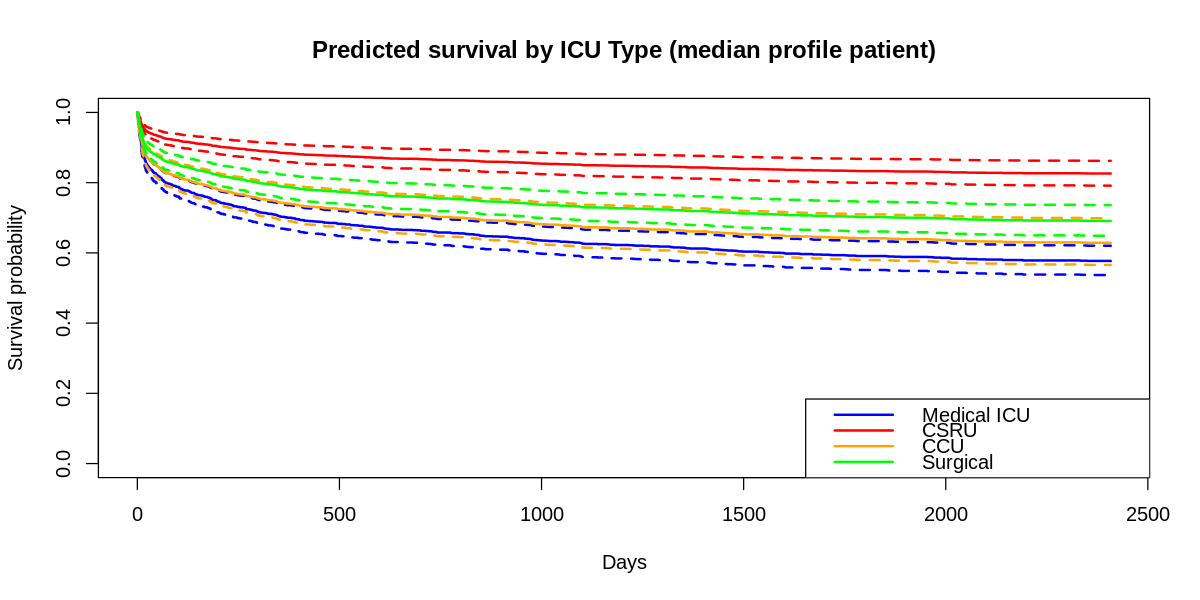

In [254]:
# Predicted survival for representative patient
median_profile <- data.frame(SAPS1 = 15, Age = 67, ICUType = "Medical ICU",  BUN_max = 20,
  Albumin_min = 3, Bilirubin_max = 0.7, Lactate_max = 2.2, RespRate_max = 27, HCO3_min = 23)

pred_medical <- median_profile
pred_csru <- median_profile; pred_csru$ICUType <- factor("Cardiac Surgery Recovery Unit",
                                                  levels = levels(df1_task2$ICUType))
pred_ccu <- median_profile; pred_ccu$ICUType <- factor("Coronary Care Unit",
                                                  levels = levels(df1_task2$ICUType))
pred_su <- median_profile; pred_su$ICUType <- factor("Surgical ICU",
                                                  levels = levels(df1_task2$ICUType))

fit_medical <- survfit(cox_final, newdata = pred_medical)
fit_csru <- survfit(cox_final, newdata = pred_csru)
fit_ccu <- survfit(cox_final, newdata = pred_ccu)
fit_su <- survfit(cox_final, newdata = pred_su)

plot(fit_medical, col = "Blue", lwd = 2, xlab = "Days", ylab = "Survival probability",
     main = "Predicted survival by ICU Type (median profile patient)")
lines(fit_csru, col = "Red", lwd = 2); lines(fit_ccu, col = "Orange", lwd = 2)
lines(fit_su, col = "Green", lwd = 2)
legend("bottomright", legend = c("Medical ICU", "CSRU", "CCU", "Surgical"),
                                 col = c("Blue", "Red", "Orange", "Green"), lwd = 2)


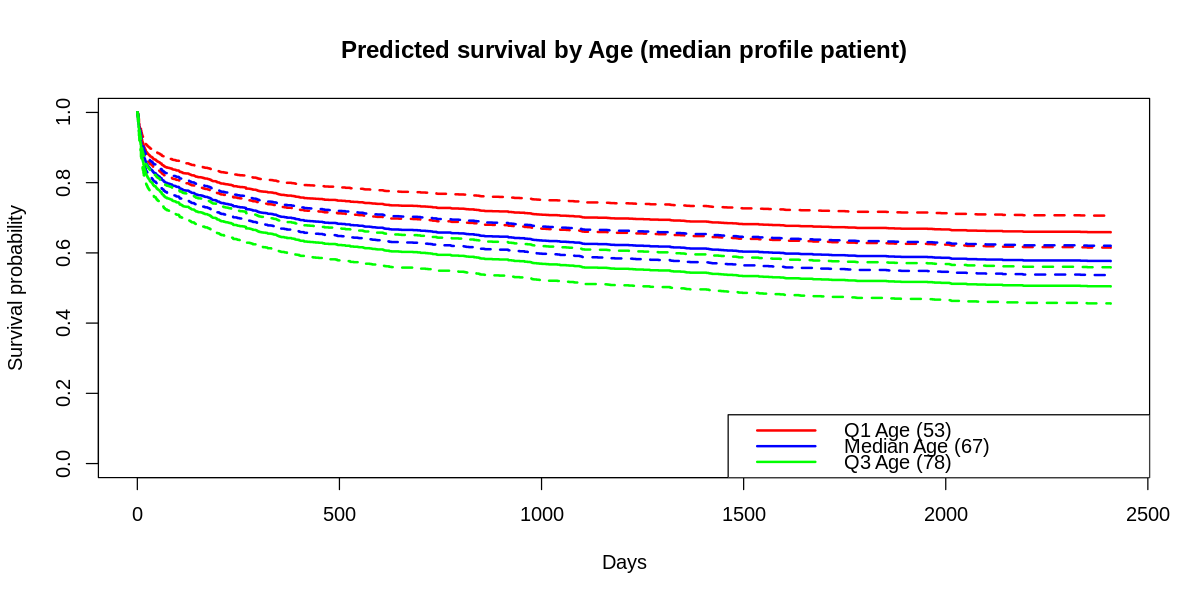

In [255]:
# Predicted survival: Age quartiles comparison
pred_age_q1 <- median_profile; pred_age_q1$Age <- 53;
pred_age_med <- median_profile;  pred_age_med$Age <- 67
pred_age_q3 <- median_profile; pred_age_q3$Age <- 78

fit_age_q1 <- survfit(cox_final, newdata = pred_age_q1)
fit_age_med <- survfit(cox_final, newdata = pred_age_med)
fit_age_q3 <- survfit(cox_final, newdata = pred_age_q3)

plot(fit_age_q1, col = "Red", lwd = 2, xlab = "Days", ylab = "Survival probability",
     main = "Predicted survival by Age (median profile patient)")
lines(fit_age_med, col = "Blue", lwd = 2); lines(fit_age_q3, col = "Green", lwd = 2)
legend("bottomright", legend = c("Q1 Age (53)", "Median Age (67)", "Q3 Age (78)"),
      col = c("Red", "Blue", "Green"), lwd = 2)

**Predicted survival:** Predicted survival probability across groups appears to drop sharply initially and then declines gradually after the first few days, reflecting the high censoring rate and relatively favourable long-term outlook for patients who survive the acute admission period. ICU type substantially affects predicted survival trajectories for a median profile patient. CSRU patients maintain the highest predicted survival (~ 82% at 2,400 days) while Medical ICU patients have the lowest (~ 58%). CCU and Surgical ICU intermediate and closely tracking each other (~ 70%). This ordering mirrors the unadjusted KM estimates and is consistent with the known differences in case mix across ICU types (CSRU admissions are predominantly planned surgical recoveries while Medical ICU patients present with acute uncontrolled illnesses). Additionally, age meaningfully separates predicted survival trajectories while holding other predictors at median values as well. A Q1 age patient (53 years) has approximately 67% predicted survival at 2,400 days compared to 57% for the median age patient (67 years) and 47% for a Q3 age patient (78 years). THis is roughly a 20% point spread across the interquartile age range, illustrating the substantial independent prognostic contribution of age beyond what SAPS1 alone captures.

In [256]:
# Refitting to unimputed dataset
cox_m0 <- coxph(Surv(Days, Status) ~ SAPS1 + Age + ICUType + BUN_max + I(BUN_max^2)
           + Albumin_min + Bilirubin_max + Lactate_max + RespRate_max + HCO3_min +
              Age:ICUType, data = icu_patients_df0)
print(round(cbind(HR = exp(coef(cox_m0)), exp(confint(cox_m0))), 3))
cat("df0 concordance:", cox_m0$concordance["concordance"], "\n")
cat("df0 AIC:", extractAIC(cox_m0)[2], "\n")

                                                   HR        2.5 %       97.5 %
SAPS1                                    1.092000e+00 9.380000e-01 1.270000e+00
Age                                      1.040000e+00 1.006000e+00 1.074000e+00
ICUTypeCoronary Care Unit                3.877191e+35 2.413027e+34 6.229772e+36
ICUTypeCardiac Surgery Recovery Unit     1.000000e+00 1.000000e+00 1.000000e+00
ICUTypeSurgical ICU                      1.600000e-02 4.000000e-03 7.200000e-02
BUN_max                                  8.780000e-01 8.590000e-01 8.980000e-01
I(BUN_max^2)                             1.002000e+00 1.001000e+00 1.002000e+00
Albumin_min                              1.620000e-01 4.900000e-02 5.390000e-01
Bilirubin_max                            1.009000e+00 9.160000e-01 1.113000e+00
Lactate_max                              1.258000e+00 1.024000e+00 1.546000e+00
RespRate_max                             9.830000e-01 9.110000e-01 1.062000e+00
HCO3_min                                

**Refit(df0):** Refitting on the unimputed dataset (df0) resulted in only 48 complete cases after listwise deletion. Key coefficient directions are broadly consistent between df0 and df1 — Lactate (HR 1.258), Albumin (HR 0.162), and Age all retain the same direction and remain significant. However, unlike the logistic regression refit, the Cox model performs markedly better on df0 — concordance improves to 0.833 (vs 0.727 in df1) and AIC drops to 116.9. This is likely an artefact of the small sample size rather than genuine model improvement as the model is likely overfitting with only 48 observations. Concordance estimates on such small samples are thus unstable and optimistic. The Wald test remains highly significant (p < 0.001) though the LRT is only borderline (p = 0.06).

The df0 coefficients show considerable instability — ICUType and its Age interaction produce implausibly large estimates with near-zero standard errors in some categories. CSRU has no estimable hazard ratio as no deaths occurred in that category after listwise deletion, causing the coefficient to default to zero with undefined standard errors. This confirms the df0 model is unreliable for inference despite the high concordance.

**Conclusion**

The final Cox model identifies SAPS1, Age, and ICUType as the dominant predictors of survival time, with their interactions revealing that the survival advantage of surgical ICU admissions diminishes with age. Physiological markers — BUN (with a nonlinear quadratic effect), Lactate, RespRate, and HCO3 — also contribute independent prognostic information beyond the composite SAPS1 score. The model achieves a concordance of 0.727, representing good discriminative ability for a complex clinical outcome, and predicted survival curves illustrate clinically meaningful differences across ICU types and age groups. The persistent proportional hazards violations in acute admission markers reflect genuine time-varying biology rather than model misspecification, and the time-splitting sensitivity analysis confirms this without changing the model structure or predictor set.

### **References**

1. Awad, A., Bader-El-Den, M., McNicholas, J., Briggs, J., & El-Sonbaty, Y. (2020). Predicting hospital mortality for ICU patients: Time series analysis. Health Informatics Journal.
Babuin, L., Vasile, V. C., Rio Perez, J. A., Alegria, J. R., Chai, H.

2. Afessa, B., Gajic, O., & Keegan, M. T. (2007). Severity of illness and organ failure assessment in adult intensive care units. *Critical Care Clinics, 23*(3), 639–658.

3. Chiu, C.-C., Wu, C.-M., Chien, T.-N., Kao, L.-J., & Qiu, J.-T. (2022). Predicting the mortality of ICU patients by topic model with machine-learning techniques. Healthcare, 10(6), 1087.

4. Ferreira, F. L., Bota, D. P., Bross, A., Mélot, C., & Vincent, J.-L. (2001). Serial evaluation of the SOFA score to predict outcome in critically ill patients. *JAMA, 286*(14), 1754–1758.

5. Gharibeh, T., Abu-Helalah, M., Alshraideh, H., Abu Awwad, M., Al Bzour, Z., Abuzayed, M., et al. (2025). Predictors of mortality in medical ICU patients: A retrospective study in a tertiary care center in Jordan. Journal of Clinical Medicine, 14(12), 4039.

6. Hang, Y., Liu, L., Chen, R., Fan, X., Sha, F., Wu, D., & Li, Y. (2025). Predicting mortality risk in the intensive care unit using a Hierarchical Inception Network for heterogeneous time series. Biomedical Signal Processing and Control, 107, 107759. https://doi.org/10.1016/j.bspc.2025.107759

7. Iwase, S., Nakada, T., Shimada, T., Oami, T., Shimazui, T., Takahashi, N., Yamabe, J., Yamao, Y., & Kawakami, E. (2022). Prediction algorithm for ICU mortality and length of stay using machine learning. Scientific Reports, 12(1), 12912.

8. Knaus, W. A., Draper, E. A., Wagner, D. P., & Zimmerman, J. E. (1985). APACHE II: a severity of disease classification system. Critical care medicine, 13(10), 818–829.

9. Le Gall, J.-R., Loirat, P., Alperovitch, A., Glaser, P., Granthil, C., Mathieu, D., Mercier, P., Thomas, R., & Villers, D. (1984). A simplified acute physiology score for ICU patients. Critical Care Medicine, 12(11), 975–977.

10. Nielsen, A. B., Thorsen-Meyer, H.-C., Belling, K., Nielsen, A. P., Thomas, C. E., Chmura, P. J., Lademann, M., Moseley, P. L., Heimann, M., Dybdahl, L., Spangsege, L., Hulsen, P., Perner, A., & Brunak, S. (2019). Survival prediction in intensive-care units based on aggregation of long-term disease history and acute physiology: A retrospective study of the Danish National Patient Registry and electronic patient records. The Lancet Digital Health, 1(2), e78–e89.

11. Ros, M. M., van der Zaag-Loonen, H. J., Hofhuis, J. G. M., & Spronk, P. E. (2021). SURvival PRediction In SEverely Ill Patients Study—The prediction of survival in critically ill patients by ICU physicians. Critical Care Explorations, 3(1), e0317. https://doi.org/10.1097/CCE.0000000000000317

12. Silva, I., Moody, G., Scott, D. J., Celi, L. A., & Mark, R. G. (2012). Predicting in-hospital mortality of ICU patients: The PhysioNet/Computing in Cardiology Challenge 2012. Computing in Cardiology, 39, 245–248.

13. Sun, H., Kang, M., Zhang, H., Jia, J., & Wang, Q. (2025). Machine learning for predicting mortality in intensive care unit patients: A prognostic performance systematic review and meta-analysis. Nursing in Critical Care, 30(6), e70206.

14. Tu, G., Cai, Z., Wu, L., Yu, H., Jiang, H., & Luo, H. (2025). Predicting in-hospital mortality in ICU patients with coronary heart disease and diabetes mellitus using machine learning models. PLOS ONE, 20(8), e0330381.

15. Vincent, J.-L., Dubois, M.-J., Navickis, R. J., & Wilkes, M. M. (2003). Hypoalbuminemia in acute illness: Is there a rationale for intervention? A meta-analysis of cohort studies and controlled trials. Annals of Surgery, 237(3), 319–334.

16. Vincent, J.-L., Moreno, R., Takala, J., Willatts, S., De Mendonça, A., Bruining, H., Reinhart, C. K., Suter, P. M., & Thijs, L. G. (1996). The SOFA (Sepsis-related Organ Failure Assessment) score to describe organ dysfunction/failure. Intensive Care Medicine, 22(7), 707–710.